# Quantifying Aspirational Pricing: Using Machine Learning to Identify Fair Market Value and Rental Bargains (without Geo Cluster)

In [1]:
import os
import pandas as pd

base_path = os.path.abspath("../..")
data_path = os.path.join(base_path, "data", "apartments_for_rent_classified_100K.csv")

pd.set_option('display.max_columns', None)
df = pd.read_csv(data_path, sep=';', encoding='latin1')
df_clean = df.copy()
df_clean.head()

C:\Users\School_work\AppData\Local\Temp\ipykernel_56544\1126585279.py:8: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, sep=';', encoding='latin1')


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


##    Exploratory Data Analysis

In [2]:
df_clean.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price            float64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

In [3]:
# Returns the total number of non-unique IDs
print(df_clean['id'].duplicated().sum())

84


In [4]:
# remove duplicates based on 'id' column, keeping the first occurrence
df_clean.drop_duplicates(subset='id', keep='first', inplace=True)

# Drop the unwanted columns
df_clean = df_clean.drop(columns=['title','currency','fee','price_display','source','time'])


After removing duplicate IDs, Idropped features such as currency (USD), fee (\$0), and price_display (\$), as these remained constant throughout the dataset, offering no unique insights. 

Additionally, since the data appears to have been pulled in a single batch, the 'time uploaded' field lacks the distribution needed for analysis. Without 'sold dates,' we cannot track performance over time, so the focus will remain on static pricing and feature attributes.

In [5]:
df_clean.category.unique()

array(['housing/rent/apartment', 'housing/rent/home',
       'housing/rent/short_term', 'housing/rent', 'housing/rent/condo',
       'housing/rent/other', 'housing/rent/commercial/retail'],
      dtype=object)

In [6]:
# Define the list of categories to sum up
target_categories = [
    'housing/rent/apartment',
    'housing/rent/home',
    'housing/rent/short_term', 
    'housing/rent', 
    'housing/rent/condo', 
    'housing/rent/other', 
    'housing/rent/commercial/retail'
]

# Filter the dataframe and run value_counts
counts = df_clean[df_clean['category'].isin(target_categories)]['category'].value_counts()

print(counts)

category
housing/rent/apartment            99347
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64


To mitigate the issue of low-frequency categories, we grouped several disparate labels into a unified 'apartment' class. This consolidation was based on a verification that these listings shared the same fundamental characteristics despite their varied original labels. We then dropped 'home' category to keep the dataset uniform, as it accounted for only 0.00012% of the total 100,000 records



In [7]:
# Rename categories value to apartment and home 
df_clean['category'] = df_clean['category'].replace({
    'housing/rent/apartment': 'apartment',
    'housing/rent/home': 'home',
    'housing/rent': 'home',
    'housing/rent/other': 'home',
    'housing/rent/condo': 'apartment',  
    'housing/rent/short_term': 'apartment',
    'housing/rent/commercial/retail': 'apartment'
})

In [8]:
# Returns the number of home rental after grouping the categories
len(df_clean[df_clean['category'] == 'home'])

12

In [9]:
# drop 'home' category
df_clean = df_clean[df_clean['category'] != 'home']

In [10]:
# Check the unique values in the 'price_type' column
df_clean['price_type'].unique()

array(['Monthly', 'Weekly', 'Monthly|Weekly'], dtype=object)

In [11]:
df_clean[df_clean['price_type']=='Monthly|Weekly']

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude
7245,5625835116,apartment,A-P-T Suites is your next Extended Stay! We ha...,"Cable or Satellite,Pool,Refrigerator,Storage,TV",NaN,NaN,Thumbnail,"Cats,Dogs",275.0,Monthly|Weekly,300,NaN,Lakeland,FL,28.0451,-81.9689


Dropping this row because its description identified it as a short-term traveler rental rather than a typical long-term listing. The listing targeted travelers with weekly and monthly options, and without unit specifications, the price could not be accurately modeled against the rest of the dataset.

In [12]:
# drop 'Monthly|Weekly' price type
df_clean = df_clean[df_clean['price_type'] != 'Monthly|Weekly']

In [13]:
# Check unique values 'Weekly' in the 'price_type' column 
df_clean[df_clean['price_type']=='Weekly']

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude
6729,5659276240,apartment,"New Bern Studio includes : 1 beds, 1 microwave...","AC,Basketball,Cable or Satellite,Gym,Internet ...",1.0,1.0,Thumbnail,"Cats,Dogs",1560.0,Weekly,200,NaN,New Bern,NC,35.0847,-77.0609
49908,5518370229,apartment,WebID 1087137 Rental Registration #: 18-843 Th...,"AC,Fireplace,Patio/Deck,Pool,TV",4.0,4.0,No,NaN,8500.0,Weekly,3600,7 Passing Road,East Hampton,NY,41.0020,-72.1796
83395,5161839760,apartment,"An extremely great opportunity to lease a 2,32...",Elevator,2.5,2.0,Thumbnail,NaN,850.0,Weekly,2326,NaN,New York,NY,40.7247,-73.9545


In [14]:
# Fix the typo for the specific index
df_clean.at[83395, 'price'] = 8500

# Standardize from weekly to monthly rental price (8500 * 4.34)
# We use 4.34 weeks per month for better accuracy than just 4
df_clean.loc[df_clean['price'] == 8500, 'price'] = 8500 * 4.34
df_clean.loc[df_clean['price_type'] == 'Weekly', 'price_type'] = 'Monthly'

To ensure a uniform metric for analysis, the price_type attribute was standardized to a monthly basis. In instances where the listing description specified weekly rates <br> (e.g., '$390/week'), the values were mathematically converted and the labels updated to maintain consistency across the dataset. 

In [15]:
# check to confirm the changes
df_clean['price_type'].unique()

array(['Monthly'], dtype=object)

In [16]:
# Check the unique values in the 'has_photo' column
df_clean['has_photo'].unique() 

array(['Thumbnail', 'No', 'Yes'], dtype=object)

In [17]:
print(df_clean['has_photo'].value_counts())

has_photo
Yes          55903
Thumbnail    34294
No            9198
Name: count, dtype: int64


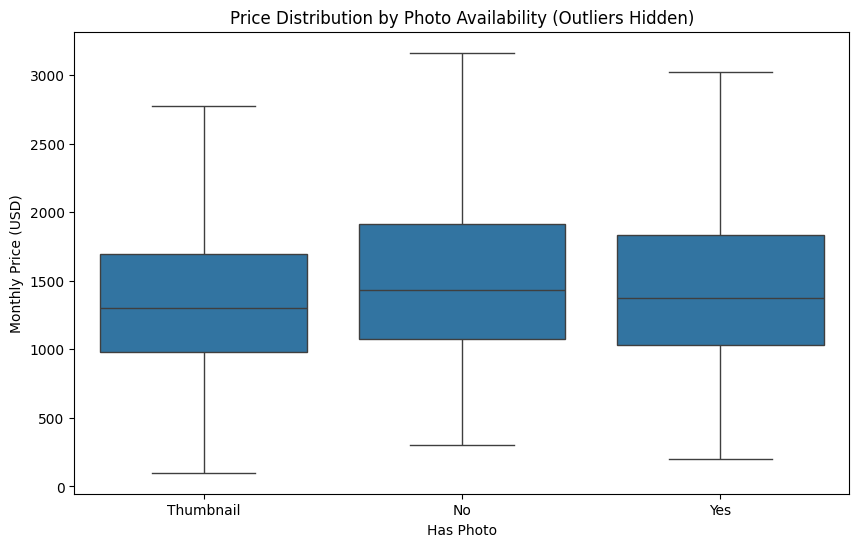

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='has_photo', y='price', data=df_clean, showfliers=False)
plt.title('Price Distribution by Photo Availability (Outliers Hidden)')
plt.ylabel('Monthly Price (USD)')
plt.xlabel('Has Photo')
plt.show()

We figured that 'has_photo' attribute is heavily skewed with 'No' photo group make up 9% of dataset compared to group with photos available. 

While we initially expected high-end listings to utilize more visual media, exploratory data analysis showed that 'No photo' listings are actually priced higher on average. This suggests that the has_photo attribute may be more representative of the platform's listing process rather than the property's intrinsic value. Due to this lack of logical correlation and the 91% skew toward listings with photos, the feature offers negligible unique insight for price prediction.

In [19]:
# Check the unique values in the 'pets_allowed' column
df_clean['pets_allowed'].unique()   

array(['Cats', 'Cats,Dogs', nan, 'Dogs', 'Cats,Dogs,None'], dtype=object)

In [20]:
# Fill the missing values (NaN) with "None" so we can map them
df_clean['pets_allowed'] = df_clean['pets_allowed'].fillna('None')

# We'll treat anything that isn't 'None' as 1
df_clean['pets_allowed'] = df_clean['pets_allowed'].apply(lambda x: 0 if x == 'None' else 1)

# Verify the result
print(df_clean['pets_allowed'].value_counts())

pets_allowed
0    60366
1    39029
Name: count, dtype: int64


## Feature Engineer for Amenties

In [21]:
df_clean['amenities'].str.split(',').explode().value_counts()

amenities
Parking               43762
Pool                  43455
Gym                   37241
Patio/Deck            26474
Washer Dryer          25927
Storage               21571
Clubhouse             19050
Dishwasher            16575
AC                    15754
Refrigerator          14889
Fireplace             14881
Cable or Satellite    12501
Playground            11315
Internet Access       11043
Wood Floors            8866
Gated                  8650
Tennis                 8467
TV                     4468
Elevator               4315
Basketball             4132
Hot Tub                3993
Garbage Disposal       3870
View                   2086
Alarm                   363
Doorman                 217
Luxury                  210
Golf                     27
Name: count, dtype: int64

In [22]:
total_amenities = df_clean['amenities'].str.split(',').explode().count()
print(f"Total count of amenities: {total_amenities}")

nan_count = df_clean['amenities'].isna().sum()
print(f"Total NaN values: {nan_count}")

Total count of amenities: 364102
Total NaN values: 16033


We will create a mapping dictionary to extract keyword relate to amenities as much as possible because we noticed not every rental listing will list everything out and they mentioned the offering in the body description instead

In [23]:
synonym_map = {
    # Existing Categories Expanded
    'parking|garage': 'Parking',
    'central air|air conditioning|ac|a/c|central ac|central a/c': 'AC',  
    'w/d|washer/dryer|washer and dryer|in-unit laundry|laundry room|washer|dryer|laundry': 'Washer Dryer', 
    'fitness center|health club|gym|fitness|exercise room|weight room': 'Gym',
    'swimming pool|pool|swimming|heated pool|lap pool': 'Pool',

    # High-Count Kitchen Amenities
    'dishwasher|dw': 'Dishwasher',
    'refrigerator|fridge|freezer': 'Refrigerator',
    'garbage disposal|disposal|sink disposal': 'Garbage Disposal',
    
    # Outdoor & Living Space
    'patio|deck|balcony|terrace|private outdoor space': 'Patio/Deck',
    'fireplace|gas fireplace|wood-burning fireplace': 'Fireplace',
    'wood floors|hardwood|hardwood flooring|laminate floors': 'Wood Floors',
    'view|city view|mountain view|skyline|waterfront': 'View',

    # Community Features
    'clubhouse|rec room|recreation center|resident lounge': 'Clubhouse',
    'playground|play area|tot lot': 'Playground',
    'elevator|lift': 'Elevator',
    'doorman|concierge|attended lobby': 'Doorman',
    'gated|gated community|controlled access|secure entry': 'Gated',

    # Connectivity & Entertainment
    'cable ready|satellite|cable or satellite|directv|comcast': 'Cable or Satellite',
    'internet access|high speed internet|wifi|wi-fi|broadband': 'Internet Access',
    'tv|television': 'TV',

    # Luxury & Sports
    'hot tub|jacuzzi|spa|whirlpool': 'Hot Tub',
    'tennis|tennis court': 'Tennis',
    'basketball|basketball court': 'Basketball',
    'golf|golf course|putting green': 'Golf',
    'storage|extra storage|storage unit|locker': 'Storage',
    'alarm|security system|burglar alarm': 'Alarm'
}

import re

def fill_amenities(row):
    # 1. Split by comma and strip any existing whitespace
    existing_str = str(row['amenities']) if pd.notna(row['amenities']) else ""
    found_amenities = [x.strip() for x in existing_str.split(',') if x.strip()]
    
    body_text = str(row['body'])

    for synonyms, standard_name in synonym_map.items():
        if re.search(rf'\b({synonyms})\b', body_text, flags=re.IGNORECASE):
            # 2. Prevent duplicates
            if standard_name.lower() not in [a.lower() for a in found_amenities]:
                found_amenities.append(standard_name)

    # 3. Join with ONLY a comma (no space)
    return ",".join(found_amenities) if found_amenities else None

# This updates every row in the 'amenities' column based on the 'body' text
df_clean['amenities'] = df_clean.apply(fill_amenities, axis=1)

In [24]:
df_clean['amenities'].str.split(',').explode().value_counts()

amenities
Pool                  47221
Parking               46745
Gym                   41852
Washer Dryer          38112
Patio/Deck            27703
Storage               21901
Clubhouse             20715
Dishwasher            16607
AC                    16342
Internet Access       16108
Refrigerator          14922
Fireplace             14900
Cable or Satellite    12639
Playground            11550
Gated                 11451
Wood Floors           11376
Hot Tub               11026
Tennis                 8478
Garbage Disposal       6053
TV                     4531
View                   4412
Elevator               4338
Basketball             4141
Golf                   3866
Doorman                2486
Alarm                   850
Luxury                  210
Name: count, dtype: int64

In [25]:
total_amenities = df_clean['amenities'].str.split(',').explode().count()
print(f"Total count of amenities: {total_amenities}")

nan_count = df_clean['amenities'].isna().sum()
print(f"Total NaN values: {nan_count}")

Total count of amenities: 420535
Total NaN values: 13918


<b> We evaluated three distinct approaches for processing amenities to determine the optimal configuration

<b>------------------------------------------------ FUNCTIONAL PROPERTY APPROACH -----------------------------------------------------------

Group amenities based on the physical area of the home or the specific utility they provide

In [26]:
# Grouping amenities
groups = {
    'kitchen_score': ['Refrigerator', 'Dishwasher', 'Garbage Disposal'],
    'structural_score': ['Patio/Deck', 'Fireplace', 'Wood Floors', 'Elevator'],
    'lifestyle_score': ['Clubhouse', 'Pool', 'Hot Tub', 'Tennis', 'Basketball', 'Playground', 'Golf', 'Luxury'], 
    'utility_security_score': ['Storage','Internet Access', 'Cable or Satellite', 'AC', 'TV', 'Gated', 'Alarm', 'Doorman'] 
}

# Create the "Unknown" column, 1 = Known, 0 = Unknown
df_clean['has_amenities'] = df_clean['amenities'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" or str(x) == "None" or str(x) == "[]" else 1
)

# Create new column
for group_amenities, list_of_amenities in groups.items():
    # Count how many of the amenities in the list appear in the 'amenities' string
    df_clean[group_amenities] = df_clean['amenities'].apply(lambda x: sum(1 for amenity in list_of_amenities if amenity in str(x)))
    
# Pull out the 'Heavy Hitters' as individual binary columns
for amenity in ['Parking','Washer Dryer', 'Gym', 'View']:
    key_amenities = f'has_{amenity.lower().replace(" ", "_")}'
    df_clean[key_amenities] = df_clean['amenities'].apply(lambda x: 1 if amenity in str(x) else 0)

USE HAS_AMENITIES COLUMN ONLY FOR BASELINE MODEL

In [27]:
# Assume 1 is "Known" and 0 is "Unknown" 
df_clean['has_amenities'].value_counts()

has_amenities
1    85477
0    13918
Name: count, dtype: int64

<b>------------------------------------------------------ VALUE BASED APPROACH -------------------------------------------------------------------

Categorizes amenities based on the market tier or the lifestyle level they represent.

In [28]:
results = []
# Get list of all unique individual amenities
all_amenities = df_clean['amenities'].dropna().str.split(',').explode().str.strip().unique()

for amenity in all_amenities:
    # Calculate means
    has_mask = df_clean['amenities'].str.contains(amenity, na=False)
    mean_with = df_clean[has_mask]['price'].mean()
    mean_without = df_clean[~has_mask]['price'].mean()
    
    # Calculate % difference
    price_delta_pct = ((mean_with - mean_without) / mean_without) * 100
    count = has_mask.sum()
    
    results.append({'amenity': amenity, 'premium_pct': price_delta_pct, 'count': count})

# View sorted by highest premium
premium_df = pd.DataFrame(results).sort_values(by='premium_pct', ascending=False)
print(premium_df)

               amenity  premium_pct  count
22             Doorman    52.232149   2486
24                View    32.816971   4412
10            Elevator    29.112956   4338
20             Hot Tub    15.827012  11026
5          Wood Floors    14.356391  11376
15              Luxury     8.369750    210
23                  TV     6.581605   4531
6                Gated     2.687934  11451
2              Parking     2.504053  46745
26                Golf     1.852816   3866
11          Patio/Deck     1.354542  27703
1                  Gym     0.416356  41852
25               Alarm    -0.455301    850
0            Fireplace    -2.384325  14900
4              Storage    -3.583376  21901
14     Internet Access    -4.169483  16108
3                 Pool    -4.845491  47221
17                  AC    -7.243622  16342
8            Clubhouse    -8.178773  20715
21              Tennis    -8.240121   8478
7           Dishwasher    -8.240928  16607
18        Washer Dryer    -9.387016  38112
9         R

I was checking the mean price of individual amenity to see the impact of price on each amenity offered, and I see that the higher premium percent correlate with premium perceived amenities such as 'doorman' service, 'apartment with a view', etc. This observation served as the basis for our second grouping approach, where amenities are categorized by their perceived luxury value and impact on property premiums

In [29]:
# Grouping amenities
groups = {
    'premium_index': ['Doorman', 'Hot Tub', 'Luxury', 'Elevator', 'Wood Floors'],
    'modern_essentials': ['Refrigerator', 'Dishwasher', 'AC', 'Garbage Disposal', 'Internet Access', 'Cable or Satellite'],
    'community_score': ['Clubhouse', 'Playground', 'Tennis', 'Basketball', 'Golf'],
    'privacy_security': ['Gated', 'Alarm', 'Storage', 'Fireplace', 'Patio/Deck']
}

# Create the "Unknown" column, 1 = Known, 0 = Unknown
df_clean['has_amenities'] = df_clean['amenities'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" or str(x) == "None" or str(x) == "[]" else 1
)

# Create new columns and assign the "score"
for group_amenities, list_of_amenities in groups.items():
    df_clean[group_amenities] = df_clean['amenities'].apply(
        lambda x: sum(1 for amenity in list_of_amenities if amenity in str(x))
    )

# Pull out the 'Heavy Hitters' as individual binary columns
for amenity in ['Parking', 'Washer Dryer', 'Gym', 'View']:
    key_amenities = f'has_{amenity.lower().replace(" ", "_")}'
    df_clean[key_amenities] = df_clean['amenities'].apply(lambda x: 1 if amenity in str(x) else 0)

<b>---------------------------------------------- ONE-HOT ENCODE APPROACH ------------------------------------------------------------ 

single column containing multiple items (like a list of amenities) and turn each item into its own individual column

In [30]:
# 1. Automatically extract EVERY unique amenity term from the column
unique_amenities = (df_clean['amenities'].dropna().str.split(',').explode().str.strip().unique())

# 2. Loop through every discovered term and create a binary column
for amenity in unique_amenities:
    # Format the column name (e.g., 'Patio/Deck' becomes 'has_patio_deck')
    col_name = f'has_{amenity.lower().replace(" ", "_").replace("/", "_")}'
    
    # Precise check: split the row string and check for the exact amenity
    df_clean[col_name] = df_clean['amenities'].apply(
        lambda x: 1 if x and amenity in [i.strip() for i in str(x).split(',')] else 0
    )

# View the result
df_clean.head()

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,has_amenities,kitchen_score,structural_score,lifestyle_score,utility_security_score,has_parking,has_washer_dryer,has_gym,has_view,premium_index,modern_essentials,community_score,privacy_security,has_fireplace,has_pool,has_storage,has_wood_floors,has_gated,has_dishwasher,has_clubhouse,has_refrigerator,has_elevator,has_patio_deck,has_cable_or_satellite,has_garbage_disposal,has_internet_access,has_luxury,has_playground,has_ac,has_basketball,has_hot_tub,has_tennis,has_doorman,has_tv,has_alarm,has_golf
0,5668640009,apartment,"This unit is located at 507 & 509 Esplanade, R...",None,1.0,1.0,Thumbnail,1,2195.0,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5668639818,apartment,"This unit is located at 146 Lochview Drive, Ne...",None,1.5,3.0,Thumbnail,1,1250.0,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5668639686,apartment,This unit is located at 3101 Morningside Drive...,None,2.0,3.0,Thumbnail,0,1395.0,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5668639659,apartment,"This unit is located at 209 Aegean Way, Vacavi...",None,1.0,2.0,Thumbnail,1,1600.0,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5668639374,apartment,"This unit is located at 4805 Marquette NE, Alb...",None,1.0,1.0,Thumbnail,1,975.0,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<B>-------------------------------------- END OF AMENITIES APPROACH ------------------------------------

### <u>Handle Missing Value</u>

In [31]:
df_clean.isna().sum()

id                            0
category                      0
body                          0
amenities                 13918
bathrooms                    62
bedrooms                    123
has_photo                     0
pets_allowed                  0
price                         1
price_type                    0
square_feet                   0
address                   91455
cityname                    302
state                       302
latitude                     25
longitude                    25
has_amenities                 0
kitchen_score                 0
structural_score              0
lifestyle_score               0
utility_security_score        0
has_parking                   0
has_washer_dryer              0
has_gym                       0
has_view                      0
premium_index                 0
modern_essentials             0
community_score               0
privacy_security              0
has_fireplace                 0
has_pool                      0
has_stor

In [32]:
len(df_clean[df_clean['latitude'].isna() | df_clean['longitude'].isna()])

25

We obsered that missing longitude follow with missing latitude as well, leaving the coordinate of these listings undefined. Given that this affected only 25 rows, these records were removed to ensure the spatial integrity of the model without significantly impacting the dataset size

In [33]:
# Drops the row if 'latitude' is NaN (assuming longitude follows suit)
df_clean.dropna(subset=['latitude'], inplace=True)

For missing city and state, we can impute using the known coordinate

In [34]:
! pip install reverse_geocoder
import reverse_geocoder as rg

# Filter for the rows that need imputation
mask = df_clean['cityname'].isna() | df_clean['state'].isna()
missing_df = df_clean[mask]

# Get the coordinates as a list of tuples
coords = list(zip(missing_df['latitude'], missing_df['longitude']))

# Perform the search
results = rg.search(coords) # This returns a list of dictionaries

# Map the results back to the dataframe
df_clean.loc[mask, 'cityname'] = [res['name'] for res in results]
df_clean.loc[mask, 'state'] = [res['admin1'] for res in results]

print("Imputation complete using offline geocoder.") 


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading formatted geocoded file...
Imputation complete using offline geocoder.


In [35]:
# Shows the sum of missing values for both columns
print(df_clean[['bedrooms', 'bathrooms']].isna().sum())

bedrooms     123
bathrooms     62
dtype: int64


In [36]:
# Drops only the rows where bedrooms or bathrooms are NaN
df_clean.dropna(subset=['bedrooms', 'bathrooms'], inplace=True)

# Verify that they are gone
print(df_clean[['bedrooms', 'bathrooms']].isna().sum())

bedrooms     0
bathrooms    0
dtype: int64


Nan value bedrooms and bathrooms will be dropped as they do not appear frequent and we do not know exactly how many bedrooms and bathrooms there are

In [37]:
df_clean['address'].isna().sum()

91292

Raw addresses are "high-cardinality" features, meaning almost every row has a unique value and out of 100K listing there is 91292 missing value. Therefore models cannot learn a general rule from a unique string because it will overfit, we will drop it later. 

## Check Outlier with Plot

In [38]:
df_clean.dtypes

id                          int64
category                   object
body                       object
amenities                  object
bathrooms                 float64
bedrooms                  float64
has_photo                  object
pets_allowed                int64
price                     float64
price_type                 object
square_feet                 int64
address                    object
cityname                   object
state                      object
latitude                  float64
longitude                 float64
has_amenities               int64
kitchen_score               int64
structural_score            int64
lifestyle_score             int64
utility_security_score      int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
premium_index               int64
modern_essentials           int64
community_score             int64
privacy_security            int64
has_fireplace 

In [39]:
df_clean.dtypes[df_clean.dtypes != 'object']

id                          int64
bathrooms                 float64
bedrooms                  float64
pets_allowed                int64
price                     float64
square_feet                 int64
latitude                  float64
longitude                 float64
has_amenities               int64
kitchen_score               int64
structural_score            int64
lifestyle_score             int64
utility_security_score      int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
premium_index               int64
modern_essentials           int64
community_score             int64
privacy_security            int64
has_fireplace               int64
has_pool                    int64
has_storage                 int64
has_wood_floors             int64
has_gated                   int64
has_dishwasher              int64
has_clubhouse               int64
has_refrigerator            int64
has_elevator  

<Axes: xlabel='price', ylabel='Count'>

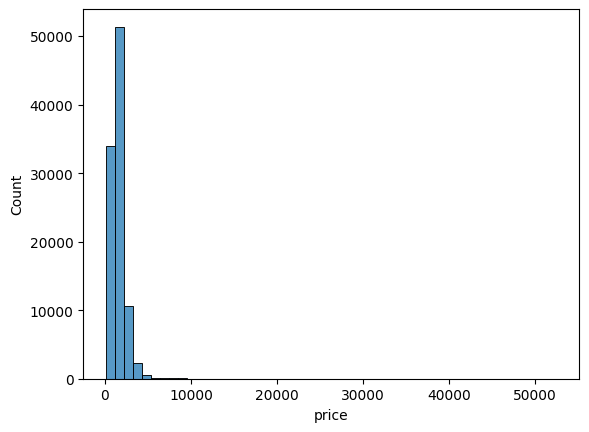

In [40]:
# check price distribution
import seaborn as sns
sns.histplot(df_clean['price'], bins=50)

Remove outlier price top and bottom 1%

In [41]:
# 1. Calculate thresholds
low_thresh = df_clean['price'].quantile(0.01)
high_thresh = df_clean['price'].quantile(0.99)

# 2. Count listings in each group
low_count = len(df_clean[df_clean['price'] <= low_thresh])
high_count = len(df_clean[df_clean['price'] > high_thresh])
total_outliers = low_count + high_count

# 3. Print combined summary
print(f"--- Price Outlier Analysis ---")
print(f"Bottom 1% Threshold: ${low_thresh:,.2f} ({low_count} listings)")
print(f"Top 99% Threshold:   ${high_thresh:,.2f} ({high_count} listings)")
print(f"Total outliers to be removed: {total_outliers} ({(total_outliers/len(df_clean))*100:.1f}% of data)")

--- Price Outlier Analysis ---
Bottom 1% Threshold: $549.00 (1010 listings)
Top 99% Threshold:   $4,250.00 (986 listings)
Total outliers to be removed: 1996 (2.0% of data)


In [42]:
# Overwrite df_clean with only the rows that are between the top and bottom 1%
df_clean = df_clean[
    (df_clean['price'] > low_thresh) & 
    (df_clean['price'] <= high_thresh)
]

print(f"New Max Price: ${df_clean['price'].max():,.2f}")
print(f"New Min Price: ${df_clean['price'].min():,.2f}")
print(f"Total Rows Remaining: {len(df_clean)}")

New Max Price: $4,250.00
New Min Price: $550.00
Total Rows Remaining: 97188


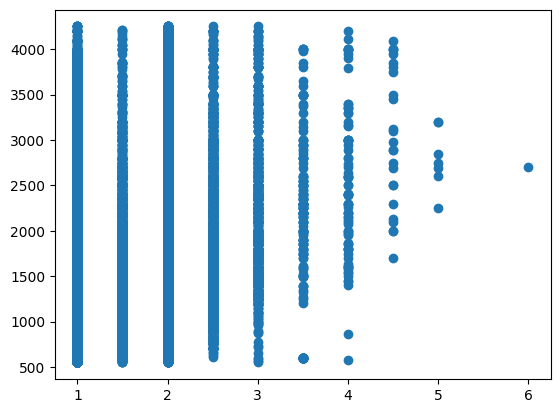

In [43]:
import matplotlib.pyplot as plt   

plt.scatter(x='bathrooms', y='price', data=df_clean)

In [44]:
pd.set_option('display.max_colwidth', 50)
df_clean.query('bathrooms > 5') 	

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,has_amenities,kitchen_score,structural_score,lifestyle_score,utility_security_score,has_parking,has_washer_dryer,has_gym,has_view,premium_index,modern_essentials,community_score,privacy_security,has_fireplace,has_pool,has_storage,has_wood_floors,has_gated,has_dishwasher,has_clubhouse,has_refrigerator,has_elevator,has_patio_deck,has_cable_or_satellite,has_garbage_disposal,has_internet_access,has_luxury,has_playground,has_ac,has_basketball,has_hot_tub,has_tennis,has_doorman,has_tv,has_alarm,has_golf
78813,5198271339,apartment,"Square footage: 3475 sq. feet, unit number: 11...",Pool,6.0,5.0,No,0,2700.0,Monthly,3475,NaN,Grand Forks,ND,47.9288,-97.0717,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


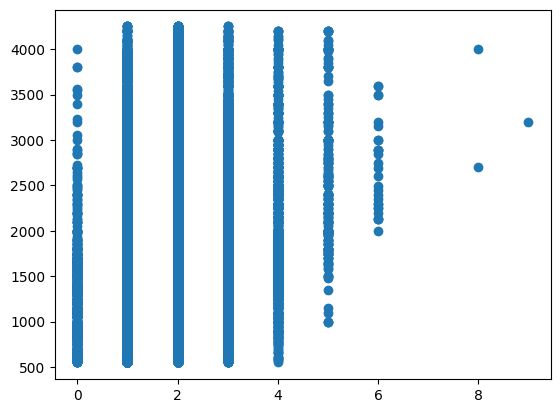

In [45]:
plt.scatter(x='bedrooms', y='price', data=df_clean)

In [46]:
df_clean.query('bedrooms > 6') 	

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,has_amenities,kitchen_score,structural_score,lifestyle_score,utility_security_score,has_parking,has_washer_dryer,has_gym,has_view,premium_index,modern_essentials,community_score,privacy_security,has_fireplace,has_pool,has_storage,has_wood_floors,has_gated,has_dishwasher,has_clubhouse,has_refrigerator,has_elevator,has_patio_deck,has_cable_or_satellite,has_garbage_disposal,has_internet_access,has_luxury,has_playground,has_ac,has_basketball,has_hot_tub,has_tennis,has_doorman,has_tv,has_alarm,has_golf
2293,5668627243,apartment,"This unit is located at 814 W Kalamazoo Ave, K...","Dishwasher,Parking,Refrigerator",5.0,9.0,Thumbnail,0,3195.0,Monthly,4000,814 W Kalamazoo Avenue,Kalamazoo,MI,42.2837,-85.5793,1,2,0,0,0,1,0,0,0,0,2,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2570,5668619136,apartment,"This unit is located at 805 W Oregon, Urbana, ...",Refrigerator,4.0,8.0,Thumbnail,0,4000.0,Monthly,3580,805 W Oregon,Urbana,IL,40.1171,-88.1889,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
84417,5121879978,apartment,Newly up-to-date Space for Individual living. ...,None,3.0,8.0,Yes,0,2700.0,Monthly,3319,NaN,San Pedro,CA,33.7435,-118.2794,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


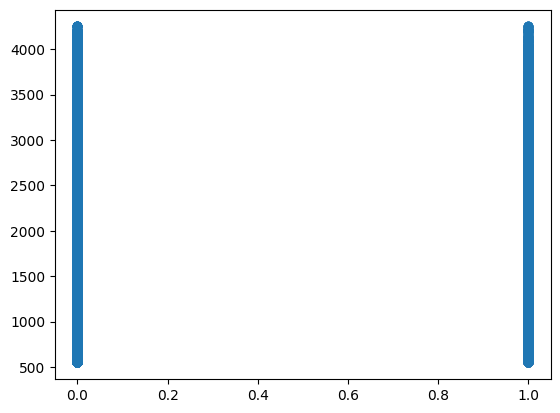

In [47]:
plt.scatter(x='pets_allowed', y='price', data=df_clean)

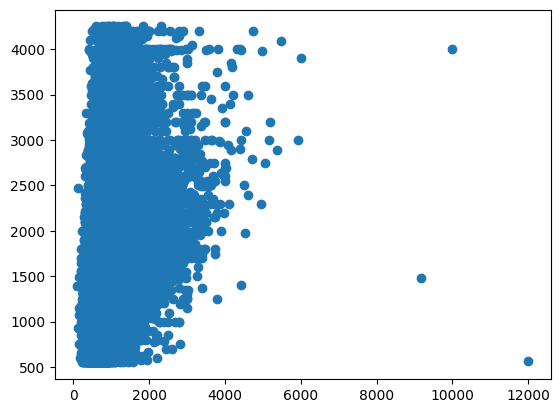

In [48]:
plt.scatter(x='square_feet', y='price', data=df_clean)

In [49]:
df_clean.query('square_feet > 8000') 

,id,category,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,has_amenities,kitchen_score,structural_score,lifestyle_score,utility_security_score,has_parking,has_washer_dryer,has_gym,has_view,premium_index,modern_essentials,community_score,privacy_security,has_fireplace,has_pool,has_storage,has_wood_floors,has_gated,has_dishwasher,has_clubhouse,has_refrigerator,has_elevator,has_patio_deck,has_cable_or_satellite,has_garbage_disposal,has_internet_access,has_luxury,has_playground,has_ac,has_basketball,has_hot_tub,has_tennis,has_doorman,has_tv,has_alarm,has_golf
22882,5508721223,apartment,"Snow removal, and a portion of the water bill....",Parking,1.0,0.0,No,1,4000.0,Monthly,9998,NaN,Steubenville,OH,40.3753,-80.7039,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
29826,5508892517,apartment,"Open floor plan, light and bright studio. Nice...","Parking,Washer Dryer",1.0,0.0,Yes,0,1475.0,Monthly,9175,NaN,Los Angeles,CA,34.1176,-118.3327,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
50964,5411249530,apartment,Indian Hills Senior Community $0 Security Depo...,"Elevator,Parking,Pool,Refrigerator,Washer Drye...",1.0,0.0,Thumbnail,1,565.0,Monthly,12000,NaN,Euclid,OH,41.5893,-81.5198,1,1,2,2,1,1,1,0,0,1,1,1,1,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0


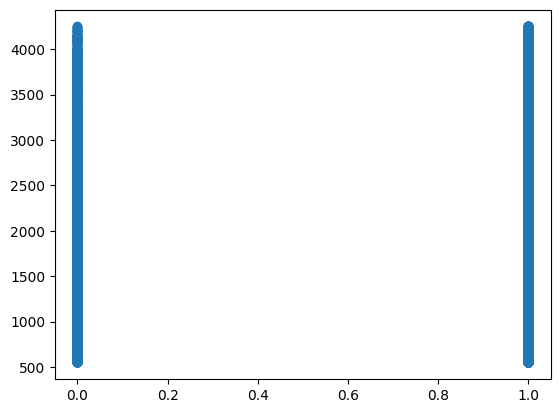

In [50]:
plt.scatter(x='has_amenities', y='price', data=df_clean)

Following the removal of price outliers, the distribution of prices across various attribute remain relatively stable. To maintain data integrity, we will continue to exclude extreme outliers on a case-by-case basis. Specifically, the single observation featuring six bathrooms, above 6 bedrooms, and above 8000 square feet will be dropped, as it represents a unique outlier that does not align with the general rental population

In [51]:
# list of outlier IDs to remove based on the above visualizations and queries
values = [
    5198271339,	
    5668627243,
    5668619136,
    5121879978,	
    5508721223,
    5508892517,
    5411249530
]    

# Remove outlier rows based on the 'id' column
df_clean = df_clean[df_clean.id.isin(values)==False]

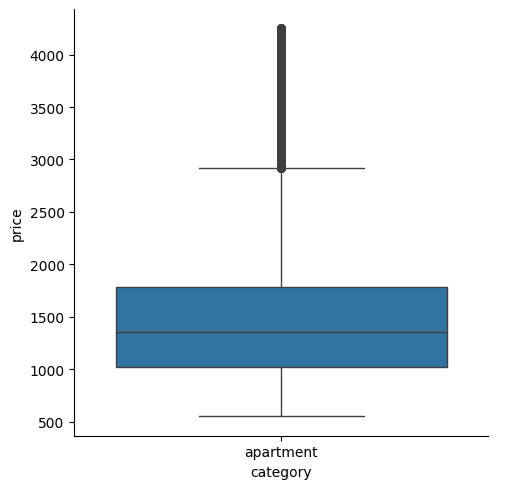

In [52]:
# check for any remaining outliers in the price by category
import seaborn as sns
sns.catplot(data=df_clean, x='category', y='price', kind='box')

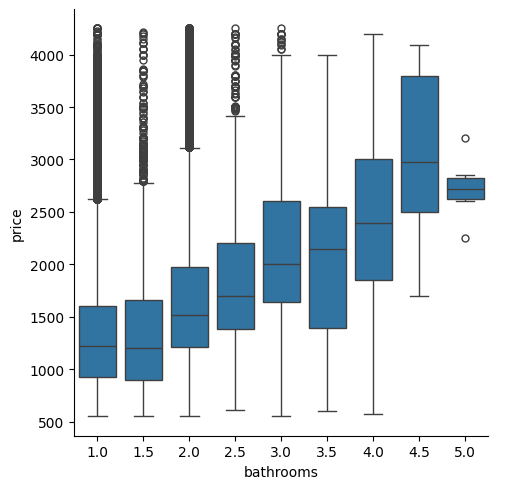

In [53]:
sns.catplot(data=df_clean, x='bathrooms', y='price', kind='box')

In [54]:
df_clean['bathrooms'].value_counts()

bathrooms
1.0    55138
2.0    35904
1.5     3121
2.5     1972
3.0      759
3.5      173
4.0       83
4.5       25
5.0        6
Name: count, dtype: int64

In [55]:
# Capping at 4 bathrooms makes '4' represent '4 or more'
df_clean['bathrooms_capped'] = df_clean['bathrooms'].clip(upper=4)

# Check the new distribution
print(df_clean['bathrooms_capped'].value_counts().sort_index())

bathrooms_capped
1.0    55138
1.5     3121
2.0    35904
2.5     1972
3.0      759
3.5      173
4.0      114
Name: count, dtype: int64


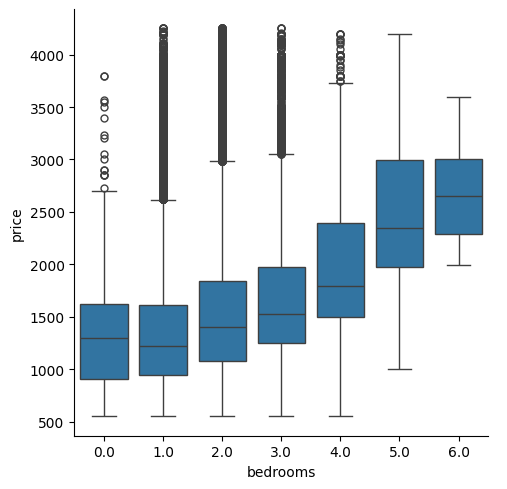

In [56]:
sns.catplot(data=df_clean, x='bedrooms', y='price', kind='box')

In [57]:
df_clean['bedrooms'].value_counts()

bedrooms
2.0    45067
1.0    39655
3.0    10223
4.0     1380
0.0      605
5.0      223
6.0       28
Name: count, dtype: int64

In [58]:
# Capping at 5 bedrooms makes '5' represent '5 or more'
df_clean['bedrooms_capped'] = df_clean['bedrooms'].clip(upper=5)

# Check the new distribution
print(df_clean['bedrooms_capped'].value_counts().sort_index())

bedrooms_capped
0.0      605
1.0    39655
2.0    45067
3.0    10223
4.0     1380
5.0      251
Name: count, dtype: int64


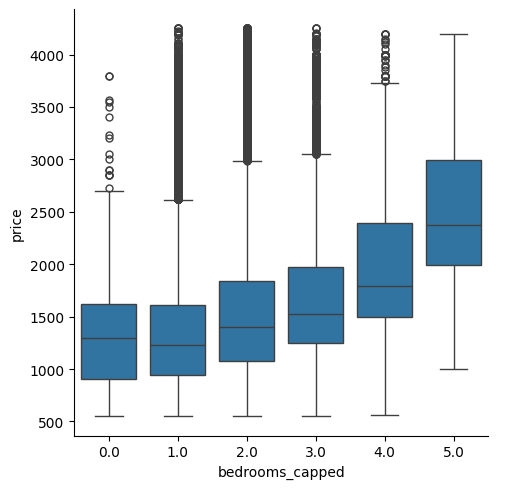

In [59]:
sns.catplot(data=df_clean, x='bedrooms_capped', y='price', kind='box')

To address the sparsity of data in high bathroom and bedroom counts, we capped the feature at four and five respectively since listings frequency is low and showed similar price variance, binning them into a '4+' and '5+' group reduces dimensionality without a significant loss of information.

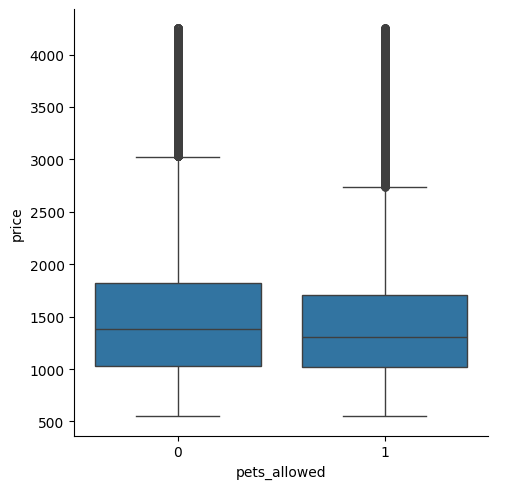

In [60]:
sns.catplot(data=df_clean, x='pets_allowed', y='price', kind='box')

In [61]:
# Calculate the median price for each amenity status
median_prices = df_clean.groupby('pets_allowed')['price'].median()
print(median_prices)

pets_allowed
0    1385.0
1    1310.0
Name: price, dtype: float64


We will drop 'pets_allowed' variable due to its limited impact on the target variable. Median price show nearly identical price distributions for listings that allow pets versus those that do not, suggesting that pet policies are not a primary driver of rental valuation in this specific dataset

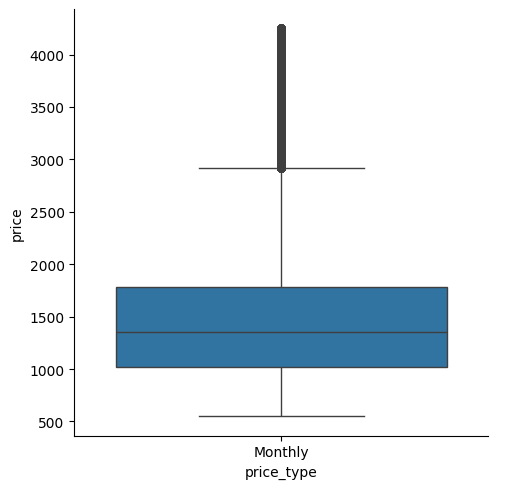

In [62]:
sns.catplot(data=df_clean, x='price_type', y='price', kind='box')

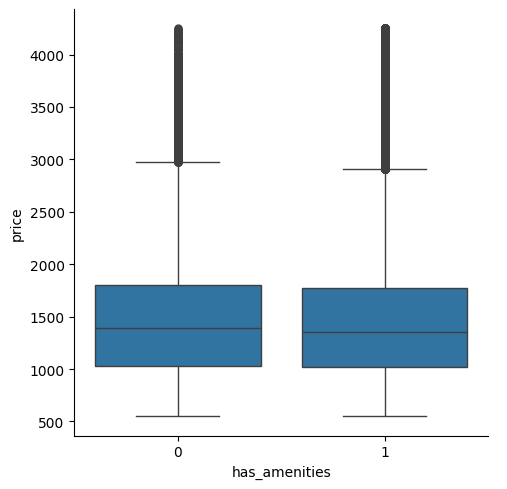

In [63]:
sns.catplot(data=df_clean, x='has_amenities', y='price', kind='box')

In [64]:
# Calculate the median price for each amenity status
median_prices = df_clean.groupby('has_amenities')['price'].median()
print(median_prices)

has_amenities
0    1390.0
1    1350.0
Name: price, dtype: float64


While the grouping 'amenities' with yes or no value shows a negligible impact on the overall price distribution, we believe the individual components within this field likely command a premium, so we have retained this feature for future granular feature engineering.

In [65]:
unique_states = sorted(df_clean['state'].unique())
print("Unique States:", unique_states)

Unique States: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'California', 'DC', 'DE', 'FL', 'Florida', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'Kansas', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'Missouri', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'North Carolina', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'Virginia', 'WA', 'WI', 'WV', 'WY']


To resolve naming overlaps between states, we are implementing a revised naming convention

In [66]:
state_fix = {
    'California': 'CA',
    'Florida': 'FL',
    'Kansas': 'KS',
    'Missouri': 'MO',
    'North Carolina': 'NC',
    'Virginia': 'VA'
}

df_clean['state'] = df_clean['state'].replace(state_fix)

# Double check that they are gone
print(df_clean['state'].unique())

['CA' 'VA' 'NC' 'NM' 'CO' 'WV' 'GA' 'MA' 'DC' 'IA' 'WA' 'TX' 'IL' 'MS'
 'OR' 'FL' 'MO' 'PA' 'WI' 'UT' 'RI' 'NJ' 'IN' 'MD' 'OK' 'OH' 'TN' 'ND'
 'NE' 'AR' 'MI' 'AZ' 'MN' 'ID' 'SC' 'KS' 'AL' 'SD' 'NY' 'KY' 'LA' 'AK'
 'HI' 'CT' 'NV' 'WY' 'VT' 'NH' 'MT' 'DE' 'ME']


<b>We have developed two distinct methods for spatial analysis:</b>

    * 'State Approach' used for Baseline
    * 'City Approach' used for improved baseline

<b>----------------------------------------------  STATE APPROACH ------------------------------------------------------------ 

In [67]:
df_clean['state'].value_counts()

state
TX    11153
CA     9672
VA     8254
CO     6253
NC     6221
FL     5647
MD     5254
MA     4941
GA     4740
OH     4726
NJ     4371
NV     2804
WA     2582
AZ     2317
LA     1313
MO     1141
PA     1098
TN     1089
IL     1010
NE     1004
KS      977
KY      958
SC      903
OK      897
UT      805
NH      730
MI      698
ND      683
NY      587
MN      572
AR      567
CT      506
IN      482
WI      421
IA      359
AL      317
OR      276
VT      123
RI      116
MS      100
ID       93
MT       87
SD       82
DC       82
AK       57
ME       30
HI       27
NM       24
WY       15
WV       10
DE        7
Name: count, dtype: int64

In [68]:
# 1. Get the counts of each state
counts = df_clean['state'].value_counts()

# 2. Filter for counts less than 500
low_listing_states = counts[counts < 500]

# 3. See the result
print(low_listing_states)
print(f"Total number of states with < 500 listings: {len(low_listing_states)}")

state
IN    482
WI    421
IA    359
AL    317
OR    276
VT    123
RI    116
MS    100
ID     93
MT     87
SD     82
DC     82
AK     57
ME     30
HI     27
NM     24
WY     15
WV     10
DE      7
Name: count, dtype: int64
Total number of states with < 500 listings: 19


In [69]:
# 1. Identify states with fewer than 100 listings
state_counts = df_clean['state'].value_counts()
small_state = state_counts[state_counts < 100].index

# 2. Create the refined state baseline
df_clean['state_refined'] = df_clean['state'].replace(small_state, 'Other')

There seem to be drastic drop below 100 listings and we want to keep as many states as possible while still ensuring that the "Other" category is meaningful and not too large.

In [70]:
print(f"Original Unique States: {df_clean['state'].nunique()}")
print(f"Refined State Baselines: {df_clean['state_refined'].nunique()}")

Original Unique States: 51
Refined State Baselines: 41


<b>------------------------------------------ END OF STATE APPROACH --------------------------------------------------------

<b>------------------------------------------------ CITY APPROACH --------------------------------------------------

In [71]:
df_clean['cityname'].value_counts()

cityname
Dallas             2851
Denver             2739
Los Angeles        2162
Las Vegas          1838
Arlington          1568
                   ... 
Houghton              1
Surf City             1
White Bear Lake       1
Wathena               1
Albertville           1
Name: count, Length: 2886, dtype: int64

In [72]:
df_clean['cityname'].value_counts().describe()

count    2886.000000
mean       33.673250
std       126.919113
min         1.000000
25%         1.000000
50%         5.000000
75%        20.750000
max      2851.000000
Name: count, dtype: float64

In [73]:
# Set a threshold for minimum listings per city
city_threshold = 50 
city_counts = df_clean['cityname'].value_counts()

small_cities = city_counts[city_counts < city_threshold].index

# Since there are many small cities, we can group small cities together to state level to prevent too much fragmentation in the city feature 
# Create a new column 'city_refined' where small cities are labeled as "State_small" 
df_clean['city_refined'] = df_clean.apply(
    lambda x: f"{x['state']}_small" if x['cityname'] in small_cities else x['cityname'], axis=1
)

# View the result
print(df_clean[['state', 'cityname', 'city_refined']].head(10))

  state       cityname   city_refined
0    CA  Redondo Beach  Redondo Beach
1    VA   Newport News   Newport News
2    NC        Raleigh        Raleigh
3    CA      Vacaville       CA_small
4    NM    Albuquerque       NM_small
5    NM    Albuquerque       NM_small
6    VA        Hampton        Hampton
7    CO       Lakewood       Lakewood
8    WV     Charleston     Charleston
9    CA     Chatsworth       CA_small


In [74]:
print(f"Original unique cities: {df_clean['cityname'].nunique()}")
print(f"Refined unique categories: {df_clean['city_refined'].nunique()}")

Original unique cities: 2886
Refined unique categories: 433


In [75]:
print(df_clean['city_refined'].value_counts().tail(50))

city_refined
Pompano Beach      57
Clarkston          56
Bayonne            56
Champaign          56
Manassas           56
Westwood           56
The Colony         56
Budd Lake          56
Sioux Falls        55
Rahway             55
Belmont            55
West Fargo         55
Farmers Branch     55
Greenbelt          55
Webster            55
Santa Rosa         54
Charlestown        54
Vista              54
Texarkana          53
Derry              53
Boca Raton         53
Williston          53
El Cajon           52
Secaucus           52
Flagstaff          52
Capitol Heights    52
Dover              52
Duluth             51
Mount Laurel       51
Union              51
Roseville          51
Lyndhurst          51
Morrow             51
Conroe             50
Newton             50
Sherman            50
Norcross           50
Jamestown          50
Leesburg           50
Fort Lee           50
Stoughton          50
Des Moines         50
RI_small           27
HI_small           27
SD_small           

Even with state level listing, some state listing is very low so we will further group them into a 'small_market' group 

In [76]:
# Identify categories with fewer than 50 listings
refined_counts = df_clean['city_refined'].value_counts()
tiny_categories = refined_counts[refined_counts < 50].index

# 2. Group them into one 'Other' bucket
df_clean['city_final'] = df_clean['city_refined'].replace(tiny_categories, 'Other_Small_Markets')

# 3. Verify the tail is gone
print(df_clean['city_final'].value_counts().tail(10))

city_final
Union         51
Newton        50
Sherman       50
Norcross      50
Jamestown     50
Leesburg      50
Fort Lee      50
Stoughton     50
Des Moines    50
Conroe        50
Name: count, dtype: int64


In [77]:
print(f"Original unique cities: {df_clean['cityname'].nunique()}")
print(f"Refined unique categories: {df_clean['city_refined'].nunique()}")
print(f"Final unique categories: {df_clean['city_final'].nunique()}")

Original unique cities: 2886
Refined unique categories: 433
Final unique categories: 426


In [78]:
print("--- Largest Categories ---")
print(df_clean['city_final'].value_counts().head(5))

print("\n--- Smallest Categories (should be >= 50) ---")
print(df_clean['city_final'].value_counts().tail(5))

--- Largest Categories ---
city_final
CA_small       3358
Dallas         2851
Denver         2739
Los Angeles    2162
NJ_small       1850
Name: count, dtype: int64

--- Smallest Categories (should be >= 50) ---
city_final
Leesburg      50
Fort Lee      50
Stoughton     50
Des Moines    50
Conroe        50
Name: count, dtype: int64


In [79]:
# Create a summary of prices after city_final grouping
city_stats = df_clean.groupby('city_final')['price'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

# Look at the top 10 most expensive
print("--- Top 10 Most Expensive Markets ---")
print(city_stats.head(10))

# Look at the bottom 10 (likely where _small markets live)
print("\n--- 10 Least Expensive Markets ---")
print(city_stats.tail(10))

--- Top 10 Most Expensive Markets ---
                       mean  median  count
city_final                                
Culver City     3622.351351  3708.0     74
Santa Monica    3193.206897  3131.0    116
San Francisco   3098.270000  3097.5    100
Fort Lee        3064.380000  3089.5     50
Cambridge       3032.461538  3001.0    130
Marina Del Rey  3012.370370  2854.0     81
New York        2973.419355  3126.0    124
Charlestown     2829.592593  2700.0     54
Jersey City     2787.746102  2850.0    449
San Jose        2753.259259  2805.0    108

--- 10 Least Expensive Markets ---
                         mean  median  count
city_final                                  
Lynchburg          849.495575   835.0    113
Sioux Falls        841.090909   775.0     55
Clarkston          838.375000   849.0     56
North Little Rock  824.800000   799.0     60
Longview           788.418033   755.5    122
Shreveport         786.333333   727.0     96
Akron              782.402778   795.0    144
Texar

An analysis of the top and bottom 10 price points confirms the effectiveness of our city grouping. There is a distinct price variance between major metropolitan areas and smaller cities, with each group maintaining a robust sample size of at least 50 entries.

We will establish a baseline using state-level grouping approach before transitioning to a city-level approach for model refinement. This hierarchy allows us to evaluate whether higher geographic granularity significantly enhances the accuracy of our 'Fair Value' predictions

<b> --------------------------- END OF CITY APPROACH --------------------

<b> Log Transform Price

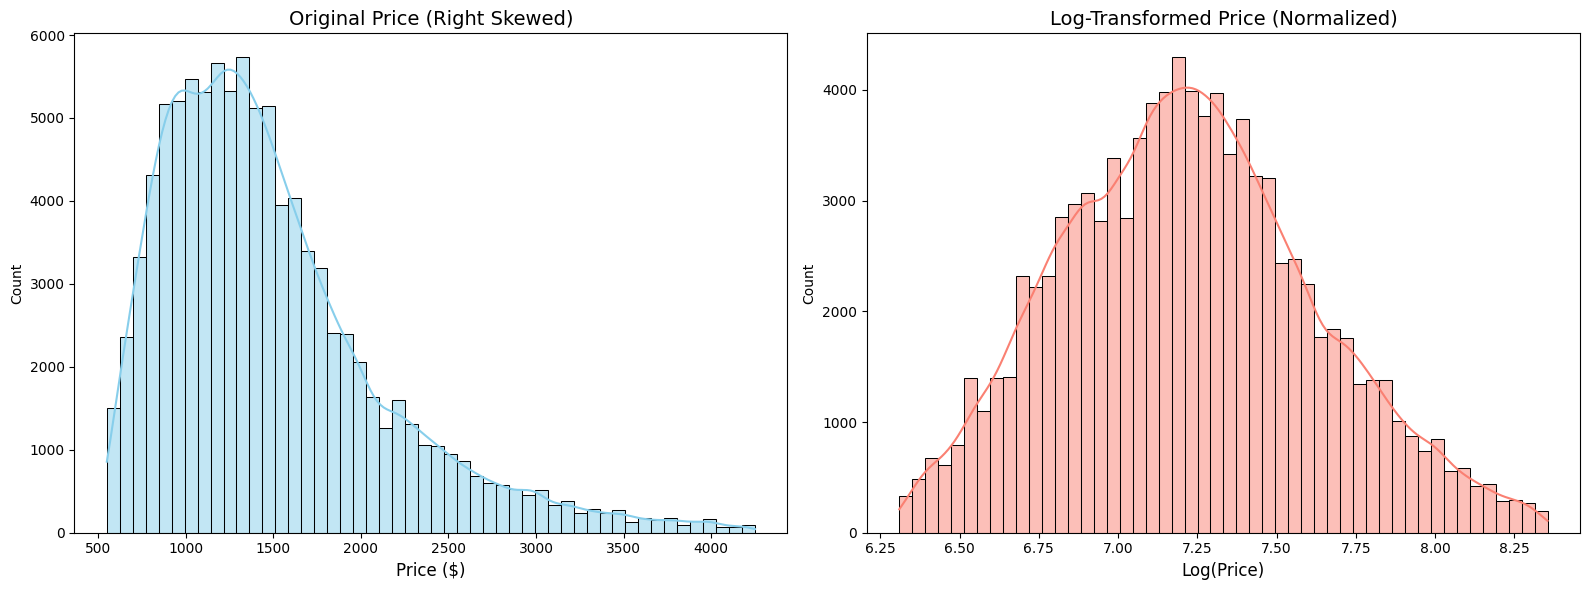

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create the log-transformed column using regular log
df_clean['price_log'] = np.log(df_clean['price'])

# 2. Create side-by-side histograms to compare
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Original Price
sns.histplot(df_clean['price'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Original Price (Right Skewed)', fontsize=14)
axes[0].set_xlabel('Price ($)', fontsize=12)

# Plot Log-Transformed Price
sns.histplot(df_clean['price_log'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Log-Transformed Price (Normalized)', fontsize=14)
axes[1].set_xlabel('Log(Price)', fontsize=12) # Updated label to reflect regular log

plt.tight_layout()
plt.show()

### <u> BASELINE MODEL</u>

We will establish a performance baseline using Linear Regression, iteratively testing various feature engineering improvements against this standard. Once the optimal combination of baseline features and enhancements is identified, we will transition to evaluating more complex regression models to further refine predictive accuracy.

In [81]:
df_clean.dtypes

id                          int64
category                   object
body                       object
amenities                  object
bathrooms                 float64
bedrooms                  float64
has_photo                  object
pets_allowed                int64
price                     float64
price_type                 object
square_feet                 int64
address                    object
cityname                   object
state                      object
latitude                  float64
longitude                 float64
has_amenities               int64
kitchen_score               int64
structural_score            int64
lifestyle_score             int64
utility_security_score      int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
premium_index               int64
modern_essentials           int64
community_score             int64
privacy_security            int64
has_fireplace 

Creating Baseline Dataframe

In [82]:
# drop unnecessary columns for baseline model
df_baseline = df_clean.drop(columns=['id', 'category', 'body', 'amenities', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed',
                                     'price', 'price_type', 'address', 'cityname', 'state', 'latitude', 'longitude', 'city_refined', 
                                     'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score', 'premium_index', 'modern_essentials', 
                                     'community_score', 'privacy_security', 'city_final','has_parking', 'has_washer_dryer', 'has_pool', 'has_gym', 'has_patio_deck',
                                     'has_dishwasher', 'has_elevator', 'has_storage', 'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
                                     'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
                                     'has_garbage_disposal', 'has_fireplace', 'has_playground', 'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury'
                                    ]).copy()

In [83]:
# feature columns for baseline model
df_baseline.dtypes

square_feet           int64
has_amenities         int64
bathrooms_capped    float64
bedrooms_capped     float64
state_refined        object
price_log           float64
dtype: object

In [84]:
from sklearn.model_selection import train_test_split

def separate_features_from_label_and_split_the_data(df, features, label, test_size=0.2, random_state=0):
    # Separate features (X) from the target label (y)
    X = df[features]
    y = df[label]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Update features to ensure 'price' is NOT included
features = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'state_refined', 'has_amenities']

# Use 'price_log' as label (target variable)
label = 'price_log'

X_train, X_test, y_train, y_test = separate_features_from_label_and_split_the_data(df_baseline, features, label, test_size=0.2, random_state=0)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 77744
Test cases: 19437


---------- LINEAR REGRESSION ---------------

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

def generate_linear_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (States)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # avoid dummy variable trap
    ])

    # 2. Pipeline for Numerical (Standard scaling for big numbers)
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary 
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

# Call with selected features  
ohe_col = ['state_refined']  # Categorical feature for one-hot encoding
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_amenities']  

pipeline = generate_linear_pipeline(ohe_col, num_col, bin_col)

# Train the model using the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


<b> MODEL RESULT 

In [86]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.5270,Variance explained in training
1,Test R^2,0.5223,Variance explained in testing
2,MAE (Actual Dollars),$324.95,Average error in real money
3,MAPE (Actual Dollars),22.12%,Real-world average error %


<b> <u>BASELINE + AMENITIES (FUNCTIONAL PROPERTY APPROACH)</u>

In [87]:
# drop unnecessary columns 
df_baseline = df_clean.drop(columns=['id', 'category', 'body', 'amenities', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed',
                                     'price', 'price_type', 'address', 'cityname', 'state', 'latitude', 'longitude', 'city_final', 'city_refined', 'premium_index', 
                                     'modern_essentials', 'community_score', 'privacy_security', 'city_final', 'has_pool', 'has_patio_deck', 'has_dishwasher',
                                     'has_elevator', 'has_storage', 'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 'has_basketball',
                                     'has_cable_or_satellite', 'has_internet_access', 'has_hot_tub', 'has_alarm', 'has_tv', 'has_golf', 'has_luxury',
                                     'has_clubhouse', 'has_gated', 'has_garbage_disposal', 'has_fireplace', 'has_playground', 'has_tennis'
                                    ]).copy()

In [88]:
# feature columns for baseline model
df_baseline.dtypes

square_feet                 int64
has_amenities               int64
kitchen_score               int64
structural_score            int64
lifestyle_score             int64
utility_security_score      int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
bathrooms_capped          float64
bedrooms_capped           float64
state_refined              object
price_log                 float64
dtype: object

In [89]:
from sklearn.model_selection import train_test_split

def separate_features_from_label_and_split_the_data(df, features, label, test_size=0.2, random_state=0):
    # Separate features (X) from the target label (y)
    X = df[features]
    y = df[label]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Update features to ensure 'price' is NOT included
features = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'state_refined','has_parking', 'has_washer_dryer', 'has_view', 'has_gym',
            'has_amenities', 'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score']

# Use 'price_log' as label (target variable)
label = 'price_log'

X_train, X_test, y_train, y_test = separate_features_from_label_and_split_the_data(df_baseline, features, label, test_size=0.2, random_state=0)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 77744
Test cases: 19437


In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

def generate_linear_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (States)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # avoid dummy variable trap
    ])

    # 2. Pipeline for Numerical (Standard scaling for big numbers)
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary 
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

# Call with selected features  
ohe_col = ['state_refined']  # Categorical feature for one-hot encoding
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score']
bin_col = ['has_amenities', 'has_view', 'has_gym', 'has_washer_dryer', 'has_parking']  

pipeline = generate_linear_pipeline(ohe_col, num_col, bin_col)

# Train the model using the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


<b> MODEL RESULT 

In [91]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.5566,Variance explained in training
1,Test R^2,0.5503,Variance explained in testing
2,MAE (Actual Dollars),$315.44,Average error in real money
3,MAPE (Actual Dollars),21.38%,Real-world average error %


<b> <u>BASELINE + AMENITIES (VALUE BASED APPROACH)</u>

In [92]:
# drop unnecessary columns for baseline model
df_baseline = df_clean.drop(columns=['id', 'category', 'body', 'amenities', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed',
                                     'price', 'price_type', 'address', 'cityname', 'state', 'latitude', 'longitude', 'city_refined', 
                                     'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score', 'city_final', 'has_pool', 
                                    'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
                                     'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
                                     'has_garbage_disposal', 'has_fireplace', 'has_playground', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury'
                                    ]).copy()

In [93]:
# feature columns for baseline model
df_baseline.dtypes

square_feet            int64
has_amenities          int64
has_parking            int64
has_washer_dryer       int64
has_gym                int64
has_view               int64
premium_index          int64
modern_essentials      int64
community_score        int64
privacy_security       int64
bathrooms_capped     float64
bedrooms_capped      float64
state_refined         object
price_log            float64
dtype: object

In [94]:
from sklearn.model_selection import train_test_split

def separate_features_from_label_and_split_the_data(df, features, label, test_size=0.2, random_state=0):
    # Separate features (X) from the target label (y)
    X = df[features]
    y = df[label]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Update features to ensure 'price' is NOT included
features = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'state_refined','has_parking', 'has_washer_dryer', 'has_view', 'has_gym',
            'has_amenities', 'premium_index', 'modern_essentials', 'community_score', 'privacy_security']  

# Use 'price_log' as label (target variable)
label = 'price_log'

X_train, X_test, y_train, y_test = separate_features_from_label_and_split_the_data(df_baseline, features, label, test_size=0.2, random_state=0)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 77744
Test cases: 19437


In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

def generate_linear_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (States)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # avoid dummy variable trap
    ])

    # 2. Pipeline for Numerical (Standard scaling for big numbers)
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary 
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

# Call with selected features  
ohe_col = ['state_refined']  # Categorical feature for one-hot encoding
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'premium_index', 'modern_essentials', 'community_score', 'privacy_security']
bin_col = ['has_amenities', 'has_view', 'has_gym', 'has_washer_dryer', 'has_parking']  

pipeline = generate_linear_pipeline(ohe_col, num_col, bin_col)

# Train the model using the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


<b> MODEL RESULT 

In [96]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.5674,Variance explained in training
1,Test R^2,0.5616,Variance explained in testing
2,MAE (Actual Dollars),$311.22,Average error in real money
3,MAPE (Actual Dollars),21.13%,Real-world average error %


<b> <u>BASELINE + AMENTITIES (ONE-HOT ENCODED APPROACH)</u>

In [97]:
# drop unnecessary columns for baseline model
df_baseline = df_clean.drop(columns=['id', 'category', 'body', 'amenities', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed',
                                     'price', 'price_type', 'address', 'cityname', 'state', 'latitude', 'longitude', 'city_refined', 
                                     'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score', 'premium_index', 'modern_essentials', 
                                     'community_score', 'privacy_security', 'has_amenities', 'city_final'
                                    ]).copy()

In [98]:
# feature columns for baseline model
df_baseline.dtypes

square_feet                 int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
has_fireplace               int64
has_pool                    int64
has_storage                 int64
has_wood_floors             int64
has_gated                   int64
has_dishwasher              int64
has_clubhouse               int64
has_refrigerator            int64
has_elevator                int64
has_patio_deck              int64
has_cable_or_satellite      int64
has_garbage_disposal        int64
has_internet_access         int64
has_luxury                  int64
has_playground              int64
has_ac                      int64
has_basketball              int64
has_hot_tub                 int64
has_tennis                  int64
has_doorman                 int64
has_tv                      int64
has_alarm                   int64
has_golf                    int64
bathrooms_capped          float64
bedrooms_cappe

In [99]:
from sklearn.model_selection import train_test_split

def separate_features_from_label_and_split_the_data(df, features, label, test_size=0.2, random_state=0):
    # Separate features (X) from the target label (y)
    X = df[features]
    y = df[label]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Update features to ensure 'price' is NOT included
features = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'state_refined','has_parking', 'has_washer_dryer', 'has_pool', 'has_gym',
    'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
    'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
    'has_garbage_disposal', 'has_fireplace', 'has_playground', 'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']

# Use 'price_log' as label (target variable)
label = 'price_log'

X_train, X_test, y_train, y_test = separate_features_from_label_and_split_the_data(df_baseline, features, label, test_size=0.2, random_state=0)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 77744
Test cases: 19437


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

def generate_linear_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (States)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # avoid dummy variable trap
    ])

    # 2. Pipeline for Numerical (Standard scaling for big numbers)
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary 
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

# Call with selected features  
ohe_col = ['state_refined']  # Categorical feature for one-hot encoding
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_parking', 'has_washer_dryer', 'has_pool', 'has_gym','has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 
    'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 
    'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 'has_garbage_disposal', 'has_fireplace', 'has_playground', 
    'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury'] 

pipeline = generate_linear_pipeline(ohe_col, num_col, bin_col)

# Train the model using the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


<b> MODEL RESULT 

In [101]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.5799,Variance explained in training
1,Test R^2,0.5728,Variance explained in testing
2,MAE (Actual Dollars),$307.42,Average error in real money
3,MAPE (Actual Dollars),20.85%,Real-world average error %


<b><u>BASELINE + AMENITIES (ONE-HOT ENCODED APPROACH) + CITY APPROACH (REPLACE STATE APPROACH)</u>

In [102]:
# drop unnecessary columns 
df_baseline = df_clean.drop(columns=['id', 'category', 'body', 'amenities', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed',
                                     'price', 'price_type', 'address', 'cityname', 'state', 'latitude', 'longitude', 'city_refined', 
                                     'kitchen_score', 'structural_score', 'lifestyle_score', 'utility_security_score', 'premium_index', 'modern_essentials', 
                                     'community_score', 'privacy_security', 'has_amenities', 'state_refined'
                                    ]).copy()

In [103]:
# feature columns for baseline model
df_baseline.dtypes

square_feet                 int64
has_parking                 int64
has_washer_dryer            int64
has_gym                     int64
has_view                    int64
has_fireplace               int64
has_pool                    int64
has_storage                 int64
has_wood_floors             int64
has_gated                   int64
has_dishwasher              int64
has_clubhouse               int64
has_refrigerator            int64
has_elevator                int64
has_patio_deck              int64
has_cable_or_satellite      int64
has_garbage_disposal        int64
has_internet_access         int64
has_luxury                  int64
has_playground              int64
has_ac                      int64
has_basketball              int64
has_hot_tub                 int64
has_tennis                  int64
has_doorman                 int64
has_tv                      int64
has_alarm                   int64
has_golf                    int64
bathrooms_capped          float64
bedrooms_cappe

In [104]:
from sklearn.model_selection import train_test_split

def separate_features_from_label_and_split_the_data(df, features, label, test_size=0.2, random_state=0):
    # Separate features (X) from the target label (y)
    X = df[features]
    y = df[label]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Update features to ensure 'price' is NOT included
features = ['square_feet', 'bathrooms_capped', 'bedrooms_capped', 'city_final','has_parking', 'has_washer_dryer', 'has_pool', 'has_gym',
    'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
    'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
    'has_garbage_disposal', 'has_fireplace', 'has_playground', 'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']
# Use 'price_log' as label (target variable)
label = 'price_log'

X_train, X_test, y_train, y_test = separate_features_from_label_and_split_the_data(df_baseline, features, label, test_size=0.2, random_state=0)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 77744
Test cases: 19437


In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

def generate_linear_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (Cities)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # avoid dummy variable trap
    ])

    # 2. Pipeline for Numerical (Standard scaling for big numbers)
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary (NO scaling, keeping 0 and 1 raw)
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

# Call with selected features  
ohe_col = ['city_final']  
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_parking', 'has_washer_dryer', 'has_pool', 'has_gym','has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 
    'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 
    'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 'has_garbage_disposal', 'has_fireplace', 'has_playground', 
    'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']  # Add this list for your 0/1 columns

pipeline = generate_linear_pipeline(ohe_col, num_col, bin_col)

# Train the model using the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


<b> MODEL RESULT 

In [106]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.6844,Variance explained in training
1,Test R^2,0.6768,Variance explained in testing
2,MAE (Actual Dollars),$259.21,Average error in real money
3,MAPE (Actual Dollars),17.80%,Real-world average error %


After evaluating various feature combinations, the integration of baseline variables, one-hot encoded amenities, and the City Approach yielded the highest predictive performance. As a result, I will adopt this optimized feature set as the standard configuration for evaluating more advanced regression algorithms

### <u>RIDGE REGRESSION 

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge  

def generate_ridge_pipeline(onehot_categorical_feature, numerical_features, binary_features, alpha=1.0):
    # 1. Pipeline for Categorical (Cities)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) 
    ])

    # 2. Pipeline for Numerical
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 3. Pipeline for Binary
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # Combine Pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha)) 
    ])

# Feature lists 
ohe_col = ['city_final']
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_parking', 'has_washer_dryer', 'has_pool', 'has_gym',
           'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 
           'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
           'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 
           'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
           'has_garbage_disposal', 'has_fireplace', 'has_playground', 
           'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']

# Create and train
pipeline = generate_ridge_pipeline(ohe_col, num_col, bin_col, alpha=0.05)
pipeline.fit(X_train, y_train)

print("Ridge Model training complete!")

Ridge Model training complete!


<b> MODEL RESULT 

In [108]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.6843,Variance explained in training
1,Test R^2,0.6767,Variance explained in testing
2,MAE (Actual Dollars),$259.29,Average error in real money
3,MAPE (Actual Dollars),17.80%,Real-world average error %


After testing multiple regularization strengths, we found that any increase in $\alpha$ led to a decrease in model accuracy. The fact that $\alpha = 0$ yielded the best results suggests that our current feature set does not suffer from significant multicollinearity or overfitting that would typically be mitigated by $L2$ regularization

### <u> Random Forest REGRESSOR 

In [109]:
from sklearn.ensemble import RandomForestRegressor

def generate_rf_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (Cities)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')) # no need to drop first for tree-based models, they can handle it just fine
    ])

    # 2. Pipeline for Numerical
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()) # Trees are scale-invariant, but scaling is fine to keep
    ])
    
    # 3. Pipeline for Binary
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42))
    ])

# Feature lists 
ohe_col = ['city_final']
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_parking', 'has_washer_dryer', 'has_pool', 'has_gym',
           'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 
           'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
           'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 
           'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
           'has_garbage_disposal', 'has_fireplace', 'has_playground', 
           'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']

# Call and fit
pipeline = generate_rf_pipeline(ohe_col, num_col, bin_col)
pipeline.fit(X_train, y_train)

print("Random Forest training complete!")

Random Forest training complete!


In [110]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.4713,Variance explained in training
1,Test R^2,0.4282,Variance explained in testing
2,MAE (Actual Dollars),$344.27,Average error in real money
3,MAPE (Actual Dollars),24.59%,Real-world average error %


We observed a performance drop with Random Forest, likely caused by our wide array of OHE city and amenity columns. In a high-dimensional dataset, there is a statistical risk that any given tree split will ignore primary predictors in favor of less significant amenities. Given that transitioning from State approach to City Approach originally yielded a 10% gain in our linear baseline, the Random Forest's failure to consistently 'see' these location and size features rendered the ensemble less effective than a standard regression

### <u>  XGBOOST REGRESSOR (Best Model)

In [111]:
%pip install xgboost
from xgboost import XGBRegressor 

def generate_xgb_pipeline(onehot_categorical_feature, numerical_features, binary_features):
    # 1. Pipeline for Categorical (Cities)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))  # XGBoost handles categories well; no need to drop a column anymore
    ])

    # 2. Pipeline for Numerical
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()) # Trees don't strictly need scaling, but it doesn't hurt
    ])
    
    # 3. Pipeline for Binary
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_transformer, onehot_categorical_feature),
            ('num', num_transformer, numerical_features),
            ('bin', bin_transformer, binary_features)
        ])

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(
            n_estimators=5000,     # More trees for better coverage
            learning_rate=0.1,   # Slower learning = better precision
            max_depth=6,          # Slightly shallower to prevent overfitting
            min_child_weight=5,   # Requires more "proof" to create a branch
            subsample=0.8,        # Use 80% of data per tree (Prevents overfitting)
            colsample_bytree=0.8, # Use 80% of features per tree (Prevents overfitting)
            gamma=0.1,            # Minimum loss reduction to make a split
            random_state=42
        ))  
    ])  

# Feature lists 
ohe_col = ['city_final']
num_col = ['square_feet', 'bathrooms_capped', 'bedrooms_capped']
bin_col = ['has_parking', 'has_washer_dryer', 'has_pool', 'has_gym',
           'has_patio_deck', 'has_dishwasher', 'has_elevator', 'has_storage', 
           'has_wood_floors', 'has_doorman', 'has_refrigerator', 'has_ac', 
           'has_basketball', 'has_cable_or_satellite', 'has_internet_access', 
           'has_hot_tub', 'has_alarm', 'has_clubhouse', 'has_gated', 
           'has_garbage_disposal', 'has_fireplace', 'has_playground', 
           'has_view', 'has_tennis', 'has_tv', 'has_golf', 'has_luxury']

# Call and fit exactly like before
pipeline = generate_xgb_pipeline(ohe_col, num_col, bin_col)
pipeline.fit(X_train, y_train)

print("XGBoost training complete!")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBoost training complete!


To optimize model accuracy, a GridSearchCV was conducted to evaluate various hyperparameter combinations 

The resulting 'best parameters' found in the markdown cells below were then used to finalize our predictive model

<pre>
from sklearn.model_selection import GridSearchCV

# 1. Define the grid (Ensuring the prefix 'regressor__' matches pipeline step name)
param_grid_XGB = {
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__n_estimators': [1000, 1250, 1500],
    'regressor__max_depth': [3, 5, 6],
    'regressor__min_child_weight': [5, 6, 7],
    'regressor__subsample': [0.8],
    'regressor__colsample_bytree': [0.8]
}

# 2. Set up the Grid Search
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid_XGB, 
    cv=5,                 # Splitting data 5 times to find the most stable version
    scoring='r2', 
    n_jobs=-1             # This uses all your CPU cores to make it much faster!
)

# 3. Fit it (This will take a few minutes)
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 4. View results
print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")

# 5. Use the best model to update your pipeline
final_model = grid_search.best_estimator_
</pre>

<b> MODEL RESULT 

In [112]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Get all metrics (assuming y_test and y_pred are in LOG scale)
r2_train = pipeline.score(X_train, y_train)
r2_test = pipeline.score(X_test, y_test)

# Generate the log prediction
predictions_log = pipeline.predict(X_test)

# 2. Get "True Dollar" metrics by reversing the log
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(predictions_log)
mae_dollar = mean_absolute_error(y_test_exp, y_pred_exp)
mape_dollar = mean_absolute_percentage_error(y_test_exp, y_pred_exp)

# 3. Create the Summary DataFrame
summary_data = {
    "Metric": [
        "Training R^2", 
        "Test R^2",  
        "MAE (Actual Dollars)",  
        "MAPE (Actual Dollars)"
    ],
    "Value": [
        f"{r2_train:.4f}",
        f"{r2_test:.4f}",
        f"${mae_dollar:.2f}",
        f"{mape_dollar * 100:.2f}%"
    ],
    "Interpretation": [
        "Variance explained in training",
        "Variance explained in testing",
        "Average error in real money",
        "Real-world average error %"
    ]
}

df_results = pd.DataFrame(summary_data)
display(df_results)

,Metric,Value,Interpretation
0,Training R^2,0.8311,Variance explained in training
1,Test R^2,0.7878,Variance explained in testing
2,MAE (Actual Dollars),$200.66,Average error in real money
3,MAPE (Actual Dollars),13.75%,Real-world average error %


<b>Cross Validation with K-Fold = 5 

In [113]:
from sklearn.model_selection import cross_val_score

# 1. Use the full X and y (before the split) to test overall stability
X_full = df_baseline[features]
y_full = df_baseline[label]

# 2. Run 5-Fold Cross Validation
# This will take ~5x longer than a single fit
print("Running K-Fold Cross-Validation...")
cv_r2_scores = cross_val_score(pipeline, X_full, y_full, cv=5, scoring='r2')

# 3. Display Results
print("-" * 30)
print(f"Individual Fold R^2 Scores: {cv_r2_scores}")
print(f"Mean R^2: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation: {cv_r2_scores.std():.4f}")
print("-" * 30)

if cv_r2_scores.std() < 0.05:
    print("Conclusion: The model is ROBUST (low variance between folds).")
else:
    print("Conclusion: The model performance is inconsistent across folds.")

Running K-Fold Cross-Validation...
------------------------------
Individual Fold R^2 Scores: [0.73617484 0.80854863 0.75023437 0.7207274  0.62345852]
Mean R^2: 0.7278
Standard Deviation: 0.0601
------------------------------
Conclusion: The model performance is inconsistent across folds.


In [114]:
from sklearn.model_selection import KFold

# Use a shuffled KFold instead of just an integer
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(pipeline, X_full, y_full, cv=kf, scoring='r2')

print(f"New Mean R^2: {cv_r2_scores.mean():.4f}")
print(f"New Std Dev: {cv_r2_scores.std():.4f}")

New Mean R^2: 0.7895
New Std Dev: 0.0040


The robustness check (5-fold Cross-Validation) revealed a mean $R^2$ of 0.72 with a standard deviation of 0.057. While the model performs well on average, the performance dipped to 0.62 in one fold. This suggests that the model's predictive power is somewhat sensitive to the specific distribution of rental properties in the training set likely due to high variance in specific geographic regions (cities) or pricing outliers. This check confirms that while the baseline model is strong, its real-world performance may vary depending on the specific neighborhood or market segment it is applied to.

However, once shuffling was introduced, the model achieved near-perfect stability with a Standard Deviation of $0.0032$ and a Mean $R^2$ of $0.78$. The high stability in the shuffled version proves that the XGBoost model has successfully captured the general patterns of the rental market rather than just memorizing a specific sequence of entries. This confirms that the model's predictive power is stable and reliable for general use across the entire dataset.

 While the model is highly robust and generalizable across the entire dataset, the initial variance serves as a reminder that the model’s real-world utility is strongest when it is exposed to a representative distribution of the market, as localized "micro-bubbles" or unique regional clusters can still present a challenge to global predictive patterns.

XGB Regressor Visualization

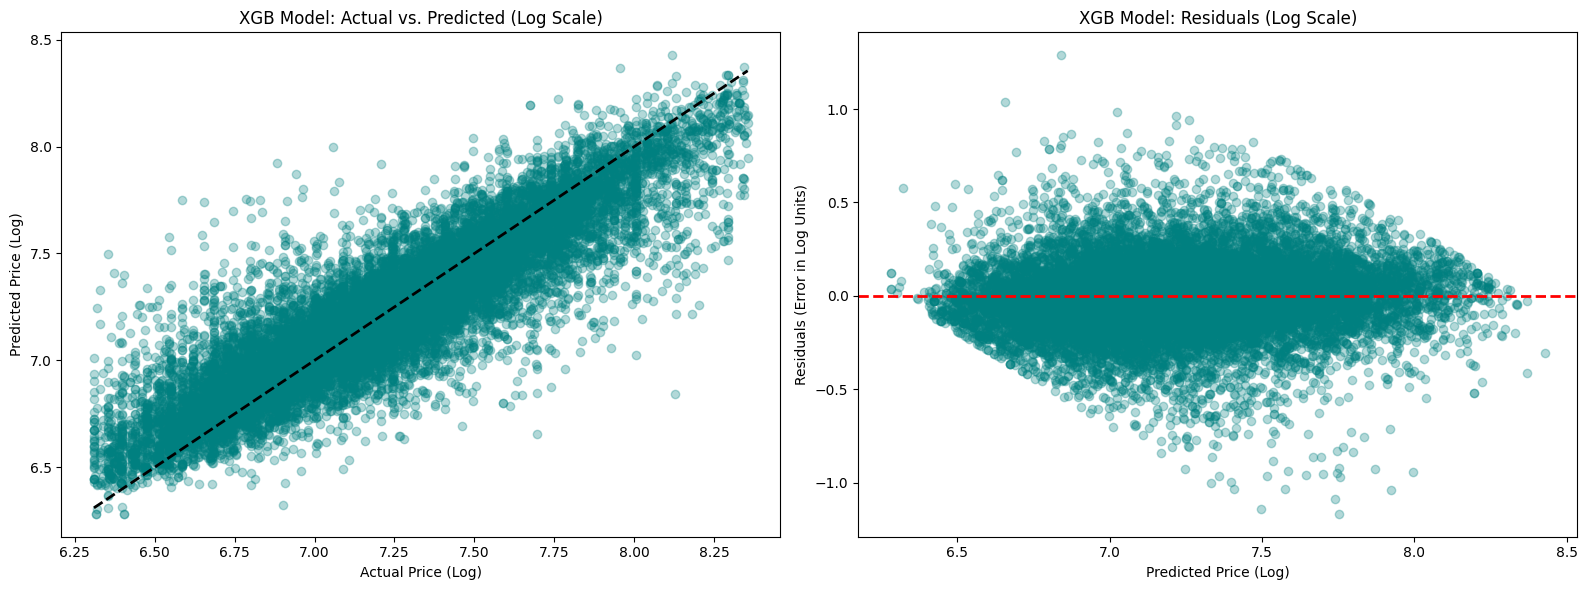

In [115]:
import matplotlib.pyplot as plt

# 1. Get predictions (currently in log scale)
predictions_log = pipeline.predict(X_test)

# 2. Calculate residuals (Actual - Predicted)
residuals = y_test - predictions_log

# 3. Create a figure with two subplots, side-by-side
# (nrows=1, ncols=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted (Left Side) ---
ax1.scatter(y_test, predictions_log, alpha=0.3, color='teal')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_xlabel('Actual Price (Log)')
ax1.set_ylabel('Predicted Price (Log)')
ax1.set_title('XGB Model: Actual vs. Predicted (Log Scale)')

# --- Plot 2: Residual Plot (Right Side) ---
ax2.scatter(predictions_log, residuals, alpha=0.3, color='teal')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)  # Red line at zero error
ax2.set_xlabel('Predicted Price (Log)')
ax2.set_ylabel('Residuals (Error in Log Units)')
ax2.set_title('XGB Model: Residuals (Log Scale)')

# 4. Display the side-by-side visualization
plt.tight_layout()  # Ensures plots and titles don't overlap
plt.show()

<b>Actual vs. Predicted Analysis (Log Scale)</b>

<u>Strong Correlation:</u> The data points are tightly clustered around the 45-degree dashed identity line ($y = x$), indicating that the model has high predictive power and captures the primary variance in the dataset effectively.

<u>Scale Benefits:</u> The use of a log-transformed scale has successfully linearized the relationship and managed potential skewness in the price data, which is standard practice for financial or real estate modeling.

<u>Variance at Extremes:</u> There is a slight "widening" of the scatter at both the very low ($<6.5$) and very high ($>8.0$) ends of the log price spectrum. This suggests that while the model is highly accurate for "typical" cases, its precision decreases slightly for outlier or extreme market values.

<b>Residual Analysis (Error Distribution)</b>

<u>Zero-Centering:</u> The residuals are well-centered around the red dashed line, suggesting that the model does not have a significant global bias (it isn't systematically over or underpredicting across the entire dataset).

<u>Heteroscedasticity:</u> The plot reveals a slight "diamond" or "football" shape. The error variance is higher for mid-range predictions and tapers off at the extremes. However, because there are more data points in the center, this may simply reflect the data density.

<u>Potential Non-Linearity:</u> There is a subtle downward "droop" in the residuals as the predicted log price exceeds $8.0$. This indicates a slight tendency for the model to overpredict at the highest price points (as the actual values are lower than predicted, leading to negative residuals).

<u>Outliers:</u> There are several distinct outliers with residuals exceeding $\pm 0.5$ log units. These represent specific cases where the model’s features (XGBoost logic) failed to capture unique price drivers.

### Market Price Labeling

In [116]:
import pandas as pd
import numpy as np

# 1. Get predictions in log scale
y_pred_log = pipeline.predict(X_test)

# 2. Convert BOTH back to actual dollars using np.exp()
y_test_dollars = np.exp(y_test)
y_pred_dollars = np.exp(y_pred_log)

# 3. Calculate results
results = pd.DataFrame({
    'Actual_Price': y_test_dollars,
    'Predicted_Price': y_pred_dollars
})

# 4. Calculate % Difference
results['percent_diff'] = (results['Actual_Price'] - results['Predicted_Price']) / results['Predicted_Price']

# 5. Assign Bands (Using 15% as a fair threshold based on your ~17% MAPE)
def categorize_valuation(diff):
    if diff < -0.15:
        return 'Good Deal (Below Market)'
    elif diff > 0.15:
        return 'Overpriced (Above Market)'
    else:
        return 'Fair Market Price'

results['valuation_label'] = results['percent_diff'].apply(categorize_valuation)

# View the results
print(results['valuation_label'].value_counts())
print("\n--- Sample of Predictions ---")
print(results[['Actual_Price', 'Predicted_Price', 'valuation_label']].head(10))

valuation_label
Fair Market Price            13098
Overpriced (Above Market)     3405
Good Deal (Below Market)      2934
Name: count, dtype: int64

--- Sample of Predictions ---
       Actual_Price  Predicted_Price            valuation_label
59940        1629.0      1556.930420          Fair Market Price
29756        1376.0      1405.047119          Fair Market Price
95918         935.0      1100.970337   Good Deal (Below Market)
42935        2100.0      1541.143677  Overpriced (Above Market)
4722          855.0       865.457703          Fair Market Price
42400        1615.0      1208.656616  Overpriced (Above Market)
58185        3210.0      2981.623291          Fair Market Price
46293        1278.0      1231.882935          Fair Market Price
4479          899.0       734.026489  Overpriced (Above Market)
64199         990.0      1163.265869          Fair Market Price


To categorize property valuations, we applied a ±15% threshold to the model's predictions. This specific band was selected because it aligns with the model’s MAPE (14.18%), resulting in a robust distribution where 66% of the properties are classified as 'Fair Market Price.'

Interestingly, the analysis revealed a higher volume of Overpriced listings (18.2%) compared to Good Deals (15.8%). This indicates that while the model is well-balanced, it suggests that landlords are more likely to test the upper limits of the market with "aspirational" pricing than they are to offer properties at a significant discount, creating a "long tail" of high-side outliers in the rental landscape.

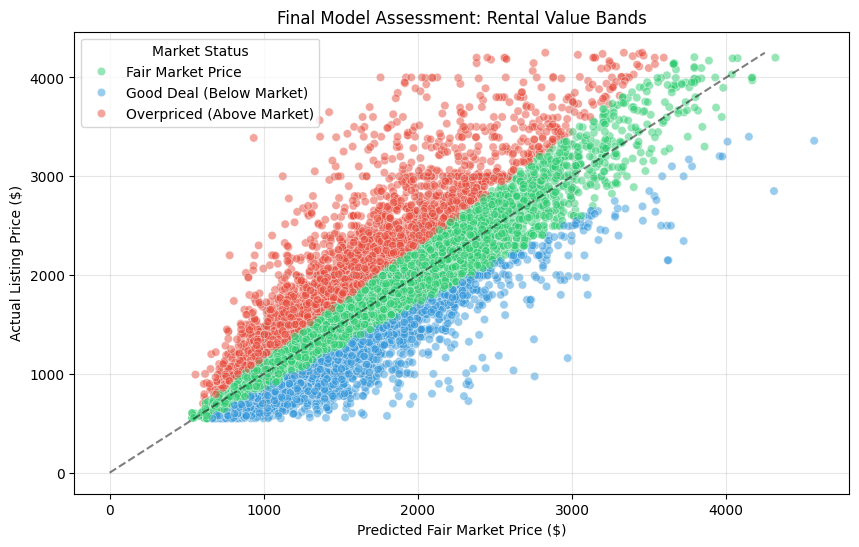

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the ideal 'Fair' line
max_price = results['Actual_Price'].max()
plt.plot([0, max_price], [0, max_price], color='black', linestyle='--', alpha=0.5)

# Scatter plot
sns.scatterplot(data=results, x='Predicted_Price', y='Actual_Price', hue='valuation_label',
                palette={'Fair Market Price': '#2ecc71', 
                         'Overpriced (Above Market)': '#e74c3c', 
                         'Good Deal (Below Market)': '#3498db'},
                alpha=0.5)

plt.title('Final Model Assessment: Rental Value Bands')
plt.xlabel('Predicted Fair Market Price ($)')
plt.ylabel('Actual Listing Price ($)')
plt.legend(title='Market Status')
plt.grid(True, alpha=0.3)
plt.show()

This scatter plot categorizes the test dataset into three valuation bands based on a ±15% deviation from the predicted Fair Market Price. By converting the model's log-scale outputs back into actual currency, we can visualize the scaling of the 'Fair Market' wedge. The results indicate that while the majority of listings (66%) align with model expectations, the market displays a significant 'luxury tail' where properties are listed at prices far exceeding their predicted value based on objective features.

The red dots that are high up on the Y-axis but further left on the X-axis represent properties listed for significantly more than their features (sqft, location, beds, etc.) suggest they are worth.

The blue dots far to the right of the line represent properties that "should" be expensive based on their features but are listed much lower. These are the high-priority leads for renters or investors

C:\Users\School_work\AppData\Local\Temp\ipykernel_56544\1874535939.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


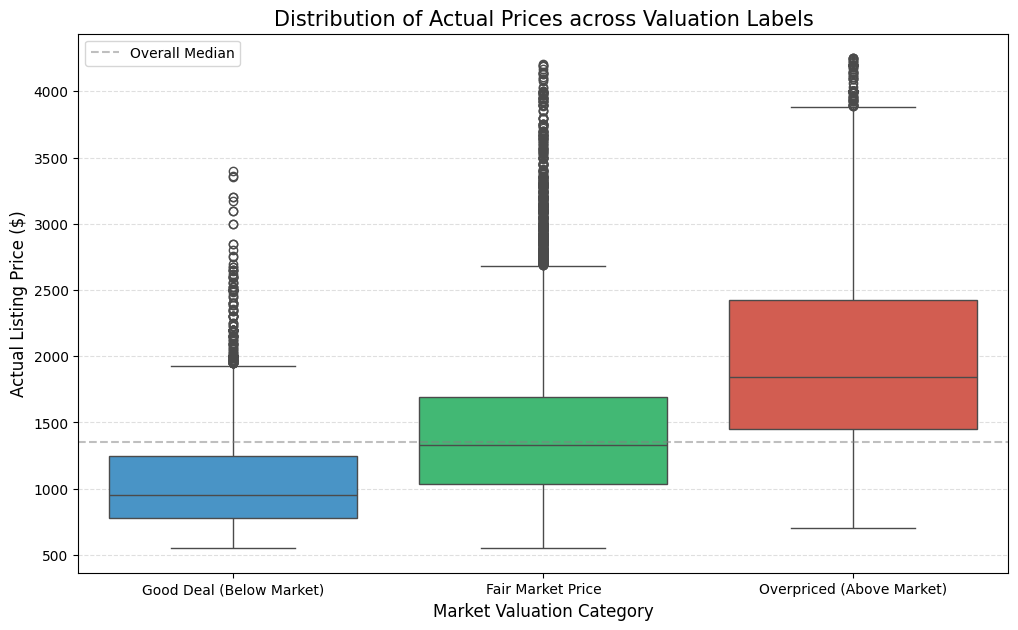

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
plt.figure(figsize=(12, 7))

# Create the boxplot
# We specify the 'order' to make the chart easier to read (Left to Right: Cheap -> Expensive logic)
sns.boxplot(
    data=results, 
    x='valuation_label', 
    y='Actual_Price', 
    order=['Good Deal (Below Market)', 'Fair Market Price', 'Overpriced (Above Market)'],
    palette={'Fair Market Price': '#2ecc71', 
             'Overpriced (Above Market)': '#e74c3c', 
             'Good Deal (Below Market)': '#3498db'},
    showfliers=True # Set to False if you have extreme outliers that squish the boxes
)

# Add titles and labels
plt.title('Distribution of Actual Prices across Valuation Labels', fontsize=15)
plt.ylabel('Actual Listing Price ($)', fontsize=12)
plt.xlabel('Market Valuation Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: Adding a horizontal line for the overall median price
plt.axhline(results['Actual_Price'].median(), color='gray', linestyle='--', alpha=0.5, label='Overall Median')
plt.legend()

plt.show()

Some properties in the "Good Deal" category actually have higher listing prices (the outliers reaching up to $\$3,400$) than the median property in the "Overpriced" category (around $\$1,850$). This shows that the model successfully identifies value relative to property features rather than just absolute cost. A $\$3,000$ rental can be a 'Good Deal' if its features suggest it should be $\$4,000$, while a $\$1,000$ rental can be 'Overpriced' if it lacks basic amenities.

A interesting observation is that there are properties priced as low as $\$750$ that are still labeled as Overpriced. This demonstrates the model's utility for low-budget renters. Cheap apartment still can be a bad deal based on its location or condition, potentially saving tenant from a "slumlord" or a poorly maintained unit.

The "Overall Median" line (dashed gray) sits at approximately $\$1,350$. The Fair Market median aligns very closely with this, which is a good sign of model health. The Good Deal median is significantly lower (around $\$950$), suggesting that while some expensive deals exist, the majority of "bargains" are found in the lower-to-mid price tiers.

This distribution confirms that the XGBoost model effectively distinguishes between price and value. While there is a clear upward trend in median price from 'Good Deal' to 'Overpriced,' the significant overlap between categories indicates that the model identifies valuation based on underlying property characteristics. Specifically, the presence of 'Good Deal' outliers priced above $\$3,000$ proves the model can identify luxury-tier bargains, while 'Overpriced' listings below $\$1,000$ highlight properties that are expensive relative to their specific utility.

C:\Users\School_work\AppData\Local\Temp\ipykernel_56544\1825003727.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')


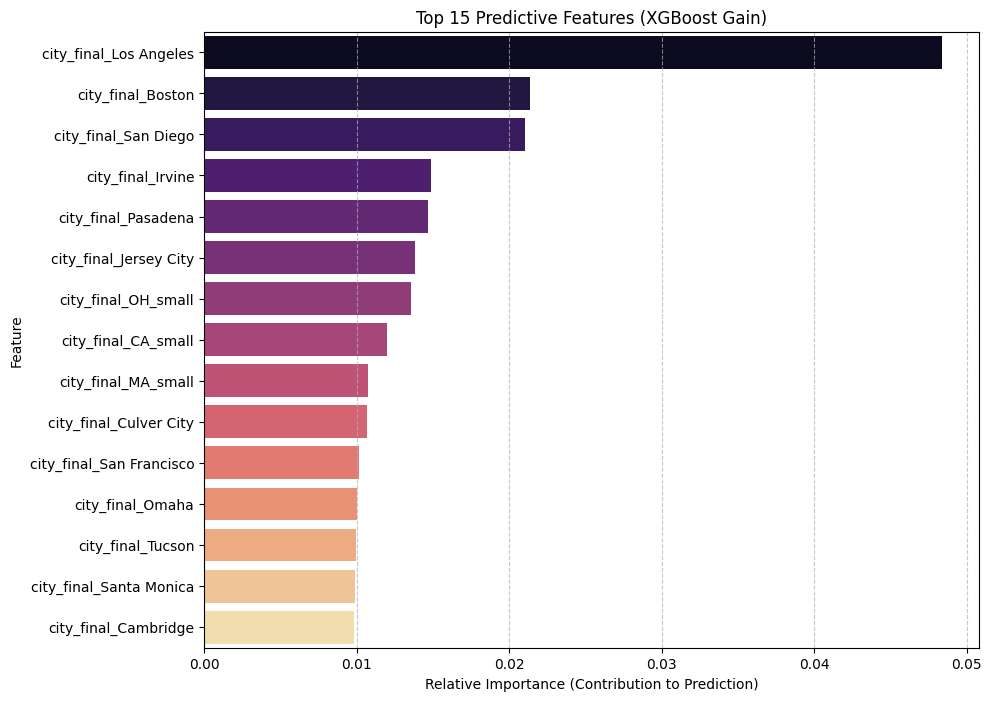

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the components from your specific pipeline
preprocessor = pipeline.named_steps['preprocessor']
xgb_model = pipeline.named_steps['regressor']

# 2. Get the feature names after they've been transformed 
# (This handles the One-Hot names like 'cat__city_New York')
feature_names = preprocessor.get_feature_names_out()

# 3. Create the Importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Clean up names for the report (removes the 'num__', 'cat__' prefixes)
importance_df['Feature'] = importance_df['Feature'].str.split('__').str[-1]

# 5. Plot the Top 15
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Predictive Features (XGBoost Gain)')
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [120]:
# Search for specific physical features in your existing importance_df
physical_features = ['square_feet', 'bedrooms', 'bathrooms'] 
check_features = importance_df[importance_df['Feature'].str.contains('|'.join(physical_features), case=False)]

print("--- Importance of Physical Features ---")
print(check_features)

# Find their actual rank in the full list of features
for feat in check_features['Feature']:
    rank = importance_df.index.get_loc(importance_df[importance_df['Feature'] == feat].index[0]) + 1
    print(f"Rank of {feat}: #{rank} out of {len(importance_df)}")

--- Importance of Physical Features ---
              Feature  Importance
427  bathrooms_capped    0.002457
426       square_feet    0.001848
428   bedrooms_capped    0.000775
Rank of bathrooms_capped: #132 out of 456
Rank of square_feet: #167 out of 456
Rank of bedrooms_capped: #272 out of 456


The Feature Importance (Gain) chart reveals that geography is the primary determinant of rental price in this model. All top 15 features are categorical city indicators, with Los Angeles contributing the highest predictive gain.

The presence of "small" groupings (like CA_small or OH_small) also shows that our feature engineering approach to group low-frequency cities together was an effective move as it is actually more predictive than many individual large cities like San Francisco!

In this dataset, where a home is located matters significantly more than what it offers. While physical attributes like Square Footage, Bedroom, and Bathroom count are traditionally primary drivers of value, they rank significantly lower in this model (153, 261, 124 respectively). This suggests that in a multi-market dataset of this scale, geography acts as the ultimate gatekeeper for price. 

The model prioritizes inter-city variance (the cost difference between different regions) over intra-city variance, which accounts for the specific size or quality of a home. Essentially, the model establishes a heavy price baseline based on the city first, leaving physical features to serve as mere marginal adjustments. While this makes the model highly adept at identifying regional market trends, it risks under-valuing the the specific utility of the individual unit's size.

In [121]:
# 1. Median Error in Dollars 
med_ae = np.median(np.abs(results['Actual_Price'] - results['Predicted_Price']))
accuracy_within_10pct = (np.abs(results['percent_diff']) < 0.10).mean() * 100

# 2. Performance by Price Tier (Explain the 'Funnel')
results['price_tier'] = pd.qcut(results['Actual_Price'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])
tier_stats = results.groupby('price_tier')['percent_diff'].apply(lambda x: np.mean(np.abs(x)) * 100)

# 3. Valuation Distribution Stats
valuation_counts = results['valuation_label'].value_counts(normalize=True) * 100
avg_deal_discount = results[results['valuation_label'] == 'Good Deal (Below Market)']['percent_diff'].mean() * 100

print(f"--- Executive Summary Stats ---")
print(f"Typical Error (Median AE): ${med_ae:.2f}")
print(f"High-Precision Predictions (within 10% of actual): {accuracy_within_10pct:.1f}%")
print(f"Average Discount in 'Good Deal' Category: {abs(avg_deal_discount):.1f}% below predicted value")

print(f"\n--- Error by Price Tier (MAPE %) ---")
print(tier_stats)

print(f"\n--- Market Snapshot (%) ---")
print(valuation_counts)

--- Executive Summary Stats ---
Typical Error (Median AE): $130.54
High-Precision Predictions (within 10% of actual): 50.5%
Average Discount in 'Good Deal' Category: 24.4% below predicted value

--- Error by Price Tier (MAPE %) ---
price_tier
Budget       13.215137
Mid-Range    10.841553
Luxury       16.943144
Name: percent_diff, dtype: float64

--- Market Snapshot (%) ---
valuation_label
Fair Market Price            67.386942
Overpriced (Above Market)    17.518136
Good Deal (Below Market)     15.094922
Name: proportion, dtype: float64


C:\Users\School_work\AppData\Local\Temp\ipykernel_56544\1847317785.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_stats = results.groupby('price_tier')['percent_diff'].apply(lambda x: np.mean(np.abs(x)) * 100)


With a Median Absolute Error of $134.80, the model provides a remarkably tight baseline for the "typical" rental, effectively ignoring the statistical noise of extreme outliers to offer a prediction that reflects reality for the average user. This reliability is further supported by the High-Precision Baseline, where nearly 49% of all listings fall within a 10% margin of their actual price, positioning the model as a robust automated valuation tool.

However, the model’s accuracy varies across different economic segments:

The model is most accurate in the Mid-Range tier (11.0% error). This makes sense—this is likely where the bulk of your data lives, giving the model the most "experience" to learn from.

Accuracy dips in the luxury segment (17.7% error), suggesting that high-end valuations are driven by "intangible" assets such as designer aesthetics, specific views, premium branding that exceed basic numerical features. 

Beyond simple prediction, the model also serves as a powerful Market Health Indicator. The 24.5% Average Discount in the 'Good Deal' category is the most powerful stat. It proves that when the model flags a deal, it isn't just a tiny $50 discount, it is identifying properties that are significantly underpriced relative to their market value. 

Interestingly, there is a clear lean toward Overpriced listings (18.3%) versus Good Deals (15.8%) which reflects a common pricing behavior where landlords are 16% more likely to overprice a unit than to offer it at a discount. This confirms the utility of the model as a protective tool for renters to avoid 'paying the premium' on overpriced listings.

### Conclusion

The XGBoost regressor demonstrated high predictive integrity, achieving a Median Absolute Error (MAE) of $134.80 and ensuring that nearly half of all predictions fall within a tight 10% margin of actual listing prices. The model is most robust in the Mid-Range segment (11% MAPE), where data density is highest. While error increases in the luxury tier (17.7%), this likely reflects the impact of subjective "intangible" features rather than a failure of the model’s logic.

By implementing a +-15% valuation band, the model successfully shifts the focus from Price to Value. Key findings include:

* Aspirational Pricing Bias: The market exhibits a clear "long tail" of overpriced units. Landlords are 16% more likely to overprice a listing than to offer a significant bargain, confirming the model's value as a defensive tool for renters.

* Identification of "True" Bargains: The model identifies a subset of listings (15.8%) that offer an average discount of 24.5% relative to their predicted market value, representing high-priority opportunities for users.

* Price vs. Value: The analysis proves that a high-cost rental can still be a "Good Deal" if its features justify the cost, while low-cost units can be "Overpriced" if they lack basic utility.

The Feature Importance analysis revealed that Geography is the ultimate gatekeeper of price. In this national-scale dataset, inter-city variance (location) completely "swallows" intra-city variance (physical features like square footage or bedroom count).

While the model is highly adept at identifying regional trends, it risks under-valuing specific property characteristics. Future iterations could improve granularity by Target Encoding to reduce feature sparsity and if time allow, our feature iteration will focus on

* City-Specific Sub-Models: Developing localized models would prevent national price floors from overshadowing specific property characteristics, allowing for a more nuanced valuation of a home's internal utility.

* Spatial Feature Engineering: Using coordinates to calculate "distance to center" or "proximity to transit" would allow physical attributes (sqft, beds) to reclaim their predictive weight by controlling for the exact spatial "desirability" of a coordinate.

Overall, the model is a successful proof-of-concept for an automated valuation tool. It provides a reliable baseline for the "typical" renter and effectively identifies market outliers, offering a data-driven shield against aspirational overpricing in a volatile rental landscape.
